## init

In [1]:
%load_ext autoreload
%autoreload 2

In [38]:
# stdlib
import ast
import copy
import itertools
from glob import glob
from pathlib import Path

# numerics / data
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.ticker import FixedLocator, MultipleLocator

# ASE
from ase import Atoms
from ase.build import fcc211
from ase.constraints import FixAtoms, FixedPlane, FixCartesian
from ase.geometry import find_mic
from ase.io import read, write, Trajectory
from ase.neb import NEB
from ase.optimize import BFGS
from ase.visualize import view

# autoadsorbate
from autoadsorbate import Fragment, Surface
from autoadsorbate.Particle import get_cube_surface_pts, grid_round_cube
from autoadsorbate.Surf import attach_fragment
from autoadsorbate.utils import get_blenderized

# cft
from cft import Manifold
from cft.mesh_interpolate import subdivide_ply_smooth_color
from cft.mesh_utils import (
    compute_outward_vertex_normals_quads,
    fit_line_and_distances,
    furthest_projected_pairs,
    get_manifold_minima,
    get_mesh_islands,
    points_close_to_rotating_line,
    values_to_colors,
)
from cft.utils import parse_vec
from cft.plot_utils import add_linear_fits
from cft.neb_utils import ForceFit, fit_raw, fit_images, plot_band, get_neb_probe, plot_barrier, get_PMD_structure

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7
})


metal_colors = {
    'Ag': '#666666',   # darker gray
    'Au': '#F6D32D',   # brighter yellow
    'Cu': '#CC5500',   # slightly darker orange
    'Pd': '#003F88',   # darker blue
    'Pt': '#9BD3F5'    # much lighter blue
}

In [3]:
from mace.calculators import mace_mp
clean_calc = mace_mp(model=
                # '/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model',
                # '/mnt/c/Users/ef/Desktop/tmp/mace-omat-0-medium.model',
                "/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model",
                head='matpes_r2scan',
                device='cpu',
                )

/home/ef/Code/CFT/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/ef/Code/CFT/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


## Data

In [5]:
DATA_DIR = Path('/mnt/c/Users/ef/Desktop/tmp/cft_paper')

### render assets

In [11]:
particle = read(DATA_DIR / 'test_particle.xyz')
slab = read(DATA_DIR / 'test_slab.xyz')

### probes

In [12]:
probes = [
    Fragment('ClC#[O+]', to_initialize=1),
    Fragment('Cl[O]', to_initialize=1),
    Fragment('Cl[C]', to_initialize=1),
    Fragment('ClO', to_initialize=1),
    Fragment('Cl[CH]', to_initialize=1),
    Fragment('Cl[CH2]', to_initialize=1),
    Fragment('ClC', to_initialize=1),
    Fragment('Cl[N]', to_initialize=1),
    Fragment('Cl[NH]', to_initialize=1),
    Fragment('ClN', to_initialize=1)
]


User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.
User requested to_initialize = 1

### isolated ref

In [14]:
neb_images = read(DATA_DIR / 'images_neb.xyz', index=':')
PMD_image = neb_images[5].copy()
PMD_image = PMD_image[[atom.index for atom in PMD_image if atom.symbol in ['C','O']]]

In [15]:
f_PMD_image =  get_neb_probe(PMD_image, keep=None)

User requested to_initialize = 1 conformers.
After pruning with 0.5; len(conformer_trj) = 1 unique conformers are found.


In [16]:
particle.calc = copy.deepcopy(clean_calc)
e_particle = particle.get_potential_energy()
PMD_image.calc = copy.deepcopy(clean_calc)
PMD_image.get_potential_energy()

PMD_CO = PMD_image[[atom.index for atom in PMD_image if atom.symbol in ['C', 'O']]]
PMD_CO.calc = copy.deepcopy(clean_calc)

O_atoms = Atoms(['O'], [[0,0,0]])
O_atoms.calc = copy.deepcopy(clean_calc)
C_atoms = Atoms(['C'], [[0,0,0]])
C_atoms.calc = copy.deepcopy(clean_calc)

isolated_ref = {
    'CO': np.sum([
        O_atoms.get_potential_energy(),
        C_atoms.get_potential_energy()
        - particle.get_potential_energy()
        ]
        ),
    'O': O_atoms.get_potential_energy(),
    'C': C_atoms.get_potential_energy(),
    'PMD_CO': PMD_CO.get_potential_energy()
}

In [28]:
file_str = DATA_DIR / 'kuma_anisotropy_results/PMD*.xyz'
file_str = file_str.as_posix()
files = glob(file_str)

phi_grid_dict = {
    'CO': {},
    'O': {},
    'C': {},
}
for file in files:
    phi = int(file.split('phi')[-1].split('.xyz')[0])
    if '_COS_' in file:        
        phi_grid_dict['CO'][phi] = read(file)
        
    elif '_CS_' in file:
        phi_grid_dict['C'][phi] = read(file)
    elif '_OS_' in file:
        phi_grid_dict['O'][phi] = read(file)


In [29]:
cu_grid = read(DATA_DIR / 'metal_Cu_211_grid.xyz')
pd_grid = read(DATA_DIR / 'metal_Pd_211_grid.xyz')
au_grid = read(DATA_DIR / 'metal_Au_211_grid.xyz')

grids_dict = {
    'Cu': {
        'e_ClC#[O+]': cu_grid,
        'e_Cl[O]': cu_grid,
        'e_Cl': cu_grid 
    },
    'Pd': {
        'e_ClC#[O+]': pd_grid,
        'e_Cl[O]': pd_grid,
        'e_Cl': pd_grid 
    },
    'Au': {
        'e_ClC#[O+]': au_grid,
        'e_Cl[O]': au_grid,
        'e_Cl': au_grid 
    },
    'HEO': {
        # 'e_ClC#[O+]': read(DATA_DIR / 'shuang_PROBE-CO_WRAPRatoms_PREC0.2_TSS2.5.xyz') ,
        # 'e_Cl[O]': read(DATA_DIR / 'shuang_PROBE-O_WRAPRatoms_PREC0.2_TSS2.5.xyz') ,
        # 'e_Cl': read(DATA_DIR / 'shuang_PROBE-H_WRAPRatoms_PREC0.2_TSS2.5.xyz') 
        'e_ClC#[O+]': read(DATA_DIR / 'shuang_PROBE-CO_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl': read(DATA_DIR / 'shuang_PROBE-H_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl[O]': read(DATA_DIR / 'shuang_PROBE-O_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl[CH2]': read(DATA_DIR / 'shuang_PROBECH2_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_ClC': read(DATA_DIR / 'shuang_PROBECH3_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl[CH]': read(DATA_DIR / 'shuang_PROBECH_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl[C]': read(DATA_DIR / 'shuang_PROBEC_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_ClN': read(DATA_DIR / 'shuang_PROBEH2N_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl[NH]': read(DATA_DIR / 'shuang_PROBEHN_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_ClO': read(DATA_DIR / 'shuang_PROBEHO_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
        'e_Cl[N]': read(DATA_DIR / 'shuang_PROBEN_WRAPRatoms_PREC0.2_TSS2.5.xyz'),
    },
    'HEA': {
        # 'e_ClC#[O+]': read(DATA_DIR / '0_CO_WRAPRatoms_PREC0.3.xyz'),
        # 'e_Cl[O]': read(DATA_DIR / '1_O_WRAPRatoms_PREC0.3.xyz'),
        # 'e_Cl': read(DATA_DIR / '0_H_WRAPRatoms_PREC0.3_TSS2.5.xyz')
        'e_ClC#[O+]': read(DATA_DIR / '0_CO_WRAPRatoms_PREC0.3.xyz'),
        'e_Cl[O]': read(DATA_DIR / '1_O_WRAPRatoms_PREC0.3.xyz'),
        'e_Cl[C]': read(DATA_DIR / '2_C_WRAPRatoms_PREC0.3.xyz'),
        'e_ClO': read(DATA_DIR / '3_HO_WRAPRatoms_PREC0.3.xyz'),
        'e_Cl[CH]': read(DATA_DIR / '4_CH_WRAPRatoms_PREC0.3.xyz'),
        'e_Cl[CH2]': read(DATA_DIR / '5_CH2_WRAPRatoms_PREC0.3.xyz'),
        'e_ClC': read(DATA_DIR / '6_CH3_WRAPRatoms_PREC0.3.xyz'),
        'e_Cl[N]': read(DATA_DIR / '7_N_WRAPRatoms_PREC0.3.xyz'),
        'e_Cl[NH]': read(DATA_DIR / '8_HN_WRAPRatoms_PREC0.3.xyz'),
        'e_ClN': read(DATA_DIR / '9_H2N_WRAPRatoms_PREC0.3.xyz'),
    },
}

HEO_slab = read(DATA_DIR / 'Co0.2Ni0.2Mg0.2Zn0.2Mn0.2Al2O4COH_311_cond2.traj')
HEO_slab = HEO_slab[[atom.index for atom in HEO_slab if atom.symbol != 'X']]

slabs_dict = {
    'Cu': read(DATA_DIR / 'metal_Cu_211_slab.xyz'),
    'Pd': read(DATA_DIR / 'metal_Pd_211_slab.xyz'),
    'Au': read(DATA_DIR / 'metal_Au_211_slab.xyz'),
    'HEO': HEO_slab,
    'HEA': read(DATA_DIR / 'test_particle.xyz'),
}


slab_refs = {}
for metal, atoms in slabs_dict.items():
    _atoms = atoms.copy()
    _atoms.calc= copy.deepcopy(clean_calc)
    e_ref = _atoms.get_potential_energy()
    slab_refs[metal] = e_ref

probe_dict = {}

for p in probes:
    _atoms = p.get_conformer(0)[1:]
    _atoms.calc= copy.deepcopy(clean_calc)
    probe_dict['e_'+p.smile] = _atoms.get_potential_energy()
    # ref_dict['e_'+p.get_chemical_formula()] = _atoms.get_potential_energy() + e_ref

## scrachpad

### ply grids

In [21]:
touch_sphere_size=2.5
precision = 0.5
m = Manifold(particle, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)
len(m.grid_atoms)

6938

In [ ]:
touch_sphere_size=2.5
precision = 2.5

m = Manifold(particle, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)
# m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/low_poly_grid.ply')
xx = m.grid_atoms.copy()
# xx.symbols = np.array(['He' for _ in m.grid_atoms])
write(f'/mnt/c/Users/ef/Desktop/tmp/atoms_hq_grid.xyz', xx)
view(m.grid_atoms)

center = np.mean(m.atoms.positions, axis=0)

diffs = m.atoms.positions - center
dists = np.linalg.norm(diffs, axis=1)
index = np.argmax(dists)
particle_radius = dists[index]

grid_radius = particle_radius + touch_sphere_size + 0.5 # 0.5 is safety buffer

xyz, _, _ =get_cube_surface_pts(radius=grid_radius, center=center, d_min=precision)
xyz*=grid_radius
xyz+=center
cube_atoms = Atoms(['He' for _ in xyz], xyz)
m.grid = cube_atoms.positions
m.normals = compute_outward_vertex_normals_quads(m.grid, m.faces)
m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/low_poly_grid_cube.ply')


round_cube_geometry = grid_round_cube(center=center, radius=grid_radius, d_min=precision)[0]
round_cube_atoms = Atoms(['He' for _ in round_cube_geometry], round_cube_geometry)
m.grid = round_cube_atoms.positions
m.normals = - round_cube_atoms.positions + center
m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/low_poly_grid_round_cube.ply')


vectors = Atoms()
for i, v in enumerate(m.grid):
    for d in np.arange(0,2,.05):
        vectors += Atoms(['H'], [v+d*m.normals[i]])

grid_atoms = m.grid_atoms.copy()
grid_atoms.symbols = ['He' for _ in grid_atoms]


lst = [cube_atoms, round_cube_atoms, grid_atoms, vectors]

for i, a in enumerate(lst):
    write(f'/mnt/c/Users/ef/Desktop/tmp/atoms_{i}.xyz', a)
    
# view(lst)

### fragment xyz

In [ ]:
smils = [
    'Cl[C]',
    'ClC',
    'S1SC([O-])C1',
    'S1SN=[NH+]1',
    'Cl[OH+]CC(O)CO',
    'Cl[n+]1ccccc1',
]

f_trj = []

for i, a in enumerate([Fragment(smi, to_initialize=3, prune_rms_thresh=0).get_conformer(1) for smi in smils]):

    if a.symbols[0]=='S':

        a.positions -= a.positions[1]*.5
        a = a[2:]

        
    else:
        a = a[1:]

    for r in np.arange(0,1.5,0.05):
        a+=Atoms(['He'], [[0,0,r]])
    f_trj.append(a)
    write(f'/mnt/c/Users/ef/Desktop/tmp/fragment_{i}.xyz', a)
view(f_trj)


In [ ]:
atoms = particle.copy()

touch_sphere_size=2.5
precision = 1.5
m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)

In [ ]:
view(atoms + m.grid_atoms)

### fragments morse

### relax / NEB benchmark

In [ ]:
relax_trj = []

for frg in [Fragment(smi, to_initialize=1).get_conformer(0) for smi in smils][:1]:
    for _i in [354, 286, 193, 132, 222]:

        a = atoms.copy()

        i = _i - len(atoms)

        attach_fragment(
            atoms = a,
            site_dict = {'coordinates': m.grid[i],'n_vector': m.normals[i],'h_vector': [1., 0., 0.]},
            fragment = frg,
            n_rotation = 0,
            height = 0,
        ) 

        a.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.number in list(set(m.atoms.get_atomic_numbers()))]))

        relax_trj.append(a)

In [ ]:
calc = mace_mp(model=
                # '/mnt/c/Users/ef/Desktop/tmp/mace-mh-nl-pbe.model',
                '/mnt/c/Users/ef/Desktop/tmp/mace-omat-0-medium.model',
                device='cpu',
                )


for i, atoms in enumerate(relax_trj):
    
    atoms.calc = calc
    traj = Trajectory(f'/mnt/c/Users/ef/Desktop/tmp/relaxation_{i}.traj', 'w', atoms)
    optimizer = BFGS(atoms, trajectory=traj)
    optimizer.run(fmax = 0.01, steps=1000)

In [ ]:
atoms = particle.copy()

touch_sphere_size=2.5
precision = 0.5
m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, calc=calc)

m.run_probe_scan(probes=[Fragment('ClC', to_initialize=1)])

In [ ]:
vals = m.grid_atoms.arrays['e_ClC'].flatten()

colors = [values_to_colors(v, vals) for v in vals]

m.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/grid_7000.ply', vertex_colors=colors)

In [ ]:
x = Atoms()
neb_points = []

for file in glob('/mnt/c/Users/ef/Desktop/tmp/relaxation_*.traj'):
    trj = read(file, index=':')
    for a in trj:
        x+=a[-1:]
    neb_points.append(trj[-1])


In [ ]:
for pair in [
    # (1,2),
    # (3,2),
    (0,1)
    ]:
    
    initial = neb_points[pair[0]].copy()
    final = neb_points[pair[1]].copy()

    n_images = 10  
    images = [initial]
    for i in range(n_images - 2):
        image = initial.copy()
        images.append(image)
    images.append(final)

    neb = NEB(images)
    neb.interpolate()

    for image in images:
        image.calc = copy.deepcopy(clean_calc)

    # --- Set up optimizer and trajectory ---
    traj = Trajectory(f'/mnt/c/Users/ef/Desktop/tmp/neb_{pair[0]}_{pair[1]}.xyz', 'w', images)

    opt = BFGS(neb, trajectory=traj)
    opt.run(fmax=0.01, steps=200)

# After completion, all images (and intermediate steps) are saved in neb.traj


In [ ]:
y = Atoms()

for file in glob('/mnt/c/Users/ef/Desktop/tmp/neb_*.xyz'):

    trj = read(file, index=':')
    for a in trj:
        y+=a[-1:]
    
write('/mnt/c/Users/ef/Desktop/tmp/neb_3_C.xyz', y)

### manifold shrink

In [ ]:
atoms = particle.copy()

touch_sphere_size=2
precision = 1.
m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, wrap_on='sites')
view(atoms + m.grid_atoms)


In [ ]:
s = Surface(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)

In [ ]:
atoms = particle.copy()
view_atoms = atoms.copy()
precision = .5
touch_sphere_size=3.6

s = Surface(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size)
sites_atoms = Atoms(['N' for _ in s.site_df.index.values],  [ v for v in s.site_df.coordinates.values])

center = np.mean(sites_atoms.positions, axis=0)
diffs = sites_atoms.positions - center
dists = np.linalg.norm(diffs, axis=1)
index = np.argmax(dists)
particle_radius = dists[index]
grid_radius = particle_radius + touch_sphere_size + 0.5 # 0.5 is safety buffer
round_cube_geometry = grid_round_cube(center=center, radius=grid_radius, d_min=precision)


site_container = Atoms()
for touch_sphere_size in np.arange(1.5, 3.6, .5):

    m = Manifold(sites_atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, grid_mode = round_cube_geometry)

    for i in [4201,4187]:
        site_container+=m.grid_atoms[i]

    print(f'{len(m.grid_atoms) = }, {touch_sphere_size = }')
    m.save_ply(filename=f'/mnt/c/Users/ef/Desktop/tmp/grid_increments_{touch_sphere_size}.ply')
    view_atoms+=m.grid_atoms
view(view_atoms[len(atoms):])
view(view_atoms)


In [ ]:
# for a in site_container:
#     a.symbol = 'He'
# write('/mnt/c/Users/ef/Desktop/tmp/grid_increments_vis.xyz', site_container)

In [ ]:
# s = Surface(atoms, mode='particle', precision=2.5, touch_sphere_size=2.5)
m = Manifold(atoms, mode='particle', precision=2.5, touch_sphere_size=2.5)

### neb in plane CO

In [ ]:
m = Manifold(particle.copy(), mode='particle', precision=.5, touch_sphere_size=2.5, wrap_on='sites')

In [ ]:
recepie = [
    [{'f' : Fragment('Cl[C]', to_initialize=1), 'site_i': 127},
    {'f' : Fragment('Cl[O]', to_initialize=1), 'site_i': 128}],
    [{'f' : Fragment('ClC#[O+]', to_initialize=1), 'site_i': 131}]
]

endpoint_trj = []
for i, ads_lst in enumerate(recepie):
    _atoms = m.atoms.copy()
    for dic in ads_lst:
        attach_fragment(
            atoms = _atoms,
            site_dict = m.site_df.iloc[dic['site_i']],
            fragment = dic['f'].get_conformer(0),
            n_rotation = 0,
            height = 1.5,
        ) 
    c1 = FixAtoms(indices=[atom.index for atom in _atoms if atom.symbol not in ['C', 'O']])
    # c2 = FixedPlane(
    #     indices=[atom.index for atom in atoms if atom.symbol in ['C', 'O']],
    #     direction=[1, 0, 0],
    # )

    indices = [atom.index for atom in _atoms if atom.symbol in ['C', 'O']]
    c2 = FixCartesian(indices, mask=(1, 0, 0))

    _atoms.set_constraint([c1,c2])
    _atoms.calc = copy.deepcopy(clean_calc)
    endpoint_trj.append(_atoms)

view(endpoint_trj)            

In [ ]:
for atoms in endpoint_trj:
    traj = Trajectory(f'/mnt/c/Users/ef/Desktop/tmp/trj_tmp.xyz', 'w')
    optimizer = BFGS(atoms, trajectory=traj, append_trajectory=True)
    optimizer.run(fmax = 0.01, steps=1000)

In [67]:
images_restart = read('/mnt/c/Users/ef/Desktop/tmp/neb_CO_in_plane.xyz', index=':')
images_restart = images_restart[-11:]

In [68]:
images_restart[0].constraints

[FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]),
 FixCartesian(indices=[55, 56], [True, False, False])]

In [69]:
restart = True

if restart == False:
    initial = endpoint_trj[0].copy()
    final = endpoint_trj[1].copy()

    n_images = 11  
    images = [initial]
    for i in range(n_images - 2):
        image = initial.copy()
        images.append(image)
    images.append(final)

    neb = NEB(images, remove_rotation_and_translation=False)
    neb.interpolate(apply_constraint=True)

else:
    images = images_restart.copy()

neb = NEB(images, remove_rotation_and_translation=False)
for image in images:
    image.calc = copy.deepcopy(clean_calc)

traj = Trajectory(f'/mnt/c/Users/ef/Desktop/tmp/neb_CO_in_plane_restart.xyz', 'w', images)

opt = BFGS(neb, trajectory=traj)
opt.run(fmax=0.1, steps=500)

/tmp/ipykernel_57184/3157250400.py:20: FutureWarning: Please import NEB from ase.mep, not ase.neb.
  neb = NEB(images, remove_rotation_and_translation=False)


      Step     Time          Energy          fmax
BFGS:    0 19:31:01    -1702.386108        0.085516


True

In [70]:
res = []
for i, image in enumerate(neb_images):
    e_neb_ref = image.get_potential_energy()
    info = {
            'image': i,
            'e_neb_ref':e_neb_ref
        }
    for k, v in {
        'C':['C'],
        'O':['O'],
        'CO':['C','O'],
        'particle':['Ag','Au','Cu','Pd','Pt'],
        'particle_C':['Ag','Au','Cu','Pd','Pt', 'C'],
        'particle_O':['Ag','Au','Cu','Pd','Pt', 'O'],
        }.items():
        
        a = image.copy()
        a = a[[atom.index for atom in a if atom.symbol in v]]
        a.calc = copy.deepcopy(clean_calc)
        e = a.get_potential_energy()
        info[f'e_{k}']= e
        
        if k == 'CO':
            info[f'd_{k}'] = a.get_all_distances()[0][1]
             
    res.append(info)

In [71]:
a = read(f'../examples/CO_neb/particle_C_field_in_plane.xyz')
ref_C = a.arrays[f'e_ClC'].flatten()[0]
ref_C = ref_C - e_particle - isolated_ref['C']

a = read(f'../examples/CO_neb/particle_O_field_in_plane.xyz')
ref_O = a.arrays[f'e_ClO'].flatten()[0]
ref_O = ref_O - e_particle - isolated_ref['O']

In [72]:
# res_df = pd.DataFrame(res)

# res_df['e_C-O'] = res_df['e_CO'] - res_df['e_C'] - res_df['e_O']
# res_df['e_C-O'] -= res_df['e_C-O'].values[0]
# res_df['e_particle_O'] -= res_df['e_particle_O'].values[0] #res_df['e_particle'] # ref_O 
# res_df['e_particle_C'] -= res_df['e_particle_C'].values[0] #res_df['e_particle'] # ref_C
# res_df['e_neb'] = res_df['e_neb_ref'] - res_df['e_neb_ref'].values[0]#res_df['e_particle']#

# res_df['sum_two_body'] = res_df['e_particle_O'] + res_df['e_particle_C'] + res_df['e_C-O']

# res_df['d_body'] = res_df['e_neb'] - res_df['sum_two_body']


# # res_df['dx'] = res_df['xx'] -res_df['e_neb']

# res_df

In [73]:
res_df = pd.DataFrame(res)

res_df['e_C-O'] = res_df['e_CO'] - isolated_ref['O'] - isolated_ref['C']
# res_df['e_C-O'] -= res_df['e_C-O'].values[0]
res_df['e_particle_O'] = res_df['e_particle_O'] - e_particle - isolated_ref['O']
res_df['e_particle_C'] = res_df['e_particle_C'] - e_particle - isolated_ref['C']
res_df['e_neb'] = res_df['e_neb_ref'] - e_particle - isolated_ref['C'] - isolated_ref['O']

res_df['sum_two_body'] = res_df['e_particle_O'] + res_df['e_particle_C'] + res_df['e_C-O']

res_df['d_body'] = res_df['e_neb'] - res_df['sum_two_body']


# res_df['dx'] = res_df['xx'] -res_df['e_neb']

res_df


,image,e_neb_ref,e_C,e_O,e_CO,d_CO,e_particle,e_particle_C,e_particle_O,e_C-O,e_neb,sum_two_body,d_body
0,0,-1703.663086,-2.560946,-3.35898,-5.885365,3.000210,-1689.560547,-5.248869,-3.096708,0.034560,-8.182613,-8.311017,0.128403
1,1,-1703.357788,-2.560946,-3.35898,-6.040423,2.790273,-1689.560547,-5.243253,-2.954374,-0.120497,-7.877315,-8.318125,0.440810
2,2,-1702.810547,-2.560946,-3.35898,-6.311290,2.553173,-1689.560547,-5.234220,-2.671782,-0.391364,-7.330074,-8.297366,0.967292
3,3,-1702.386108,-2.560946,-3.35898,-6.752419,2.248612,-1689.560547,-5.237150,-2.437162,-0.832494,-6.905636,-8.506806,1.601170
4,4,-1703.247070,-2.560946,-3.35898,-9.877807,1.742626,-1689.560547,-4.911711,-2.432524,-3.957881,-7.766598,-11.302115,3.535517
5,5,-1706.135254,-2.560946,-3.35898,-15.645775,1.264509,-1689.560547,-4.301359,-2.220976,-9.725849,-10.654781,-16.248184,5.593403
6,6,-1706.925659,-2.560946,-3.35898,-16.231354,1.192185,-1689.560547,-4.197965,-1.543974,-10.311428,-11.445186,-16.053367,4.608181
7,7,-1707.338257,-2.560946,-3.35898,-16.287983,1.181675,-1689.560547,-4.406095,-1.021513,-10.368057,-11.857784,-15.795665,3.937881
8,8,-1707.574341,-2.560946,-3.35898,-16.316353,1.175653,-1689.560547,-4.555143,-0.746977,-10.396427,-12.093868,-15.698547,3.604679
9,9,-1707.622437,-2.560946,-3.35898,-16.385983,1.156103,-1689.560547,-3.621916,-0.459990,-10.466057,-12.141964,-14.547962,2.405998


In [74]:
res_df['e_particle_O'].values[0] - res_df['e_particle_O'].values[-1]
res_df['e_particle_C'].values[0] - res_df['e_particle_C'].values[-1]
# res_df['e_C-O'].values[0] - res_df['e_C-O'].values[-1]

path = [0]
for i in range(len(neb_images) - 1):
    # positions = neb_images[0].positions
    dR = neb_images[i + 1].positions - neb_images[i].positions
    dR, _ = find_mic(dR, neb_images[i].cell, neb_images[i].pbc)
    path.append(path[i] + np.sqrt((dR**2).sum()))
res_df['path'] = path


In [75]:
grd_CO= read(f'../examples/CO_neb/particle_CO_field_in_plane.xyz')

a = neb_images[-1].copy()
pos = a[[atom. index for atom in a if atom.symbol == 'C']].positions[0]
dr = np.linalg.norm(grd_CO.positions - pos, axis=1)

field_CO = grd_CO.arrays['e_ClC#O+']
field_CO = field_CO - isolated_ref['O'] - isolated_ref['C']

CO_at_star = field_CO[np.argmin(dr)]


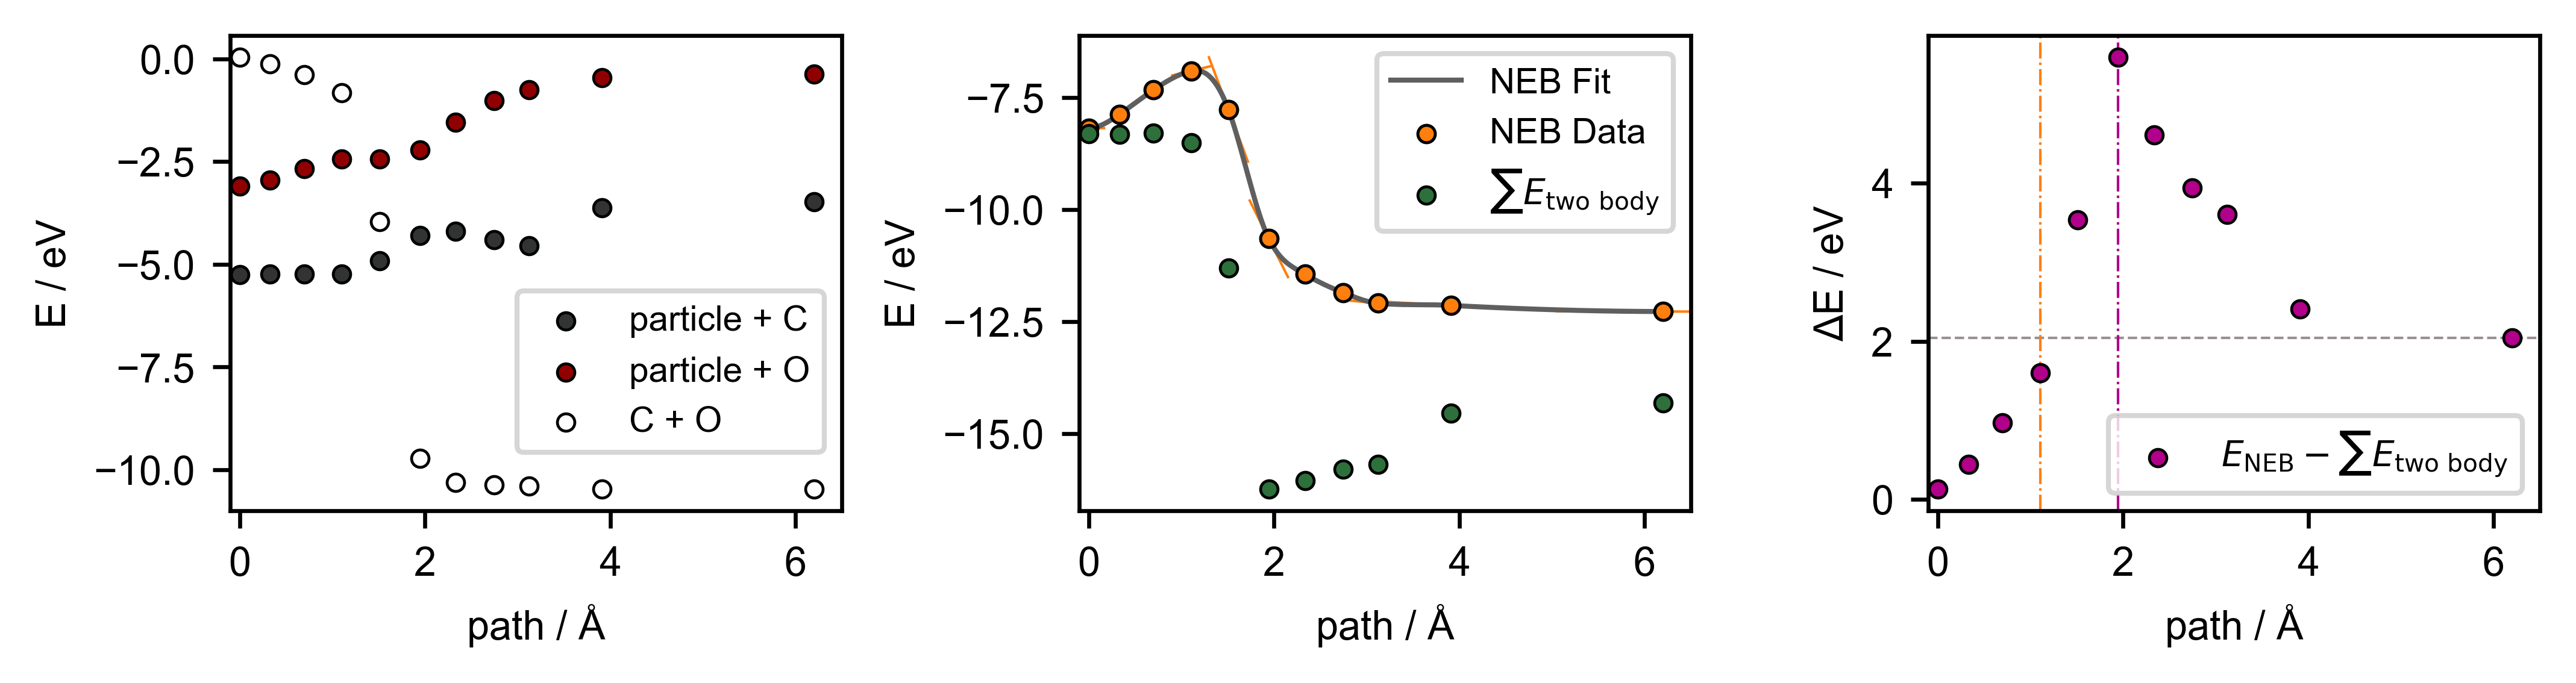

In [78]:
lw_pt = 0.2 * 72 / 25.4  # 0.2 mm in points

fig, axs = plt.subplots(
    1, 3,
    figsize=[182/25.4, 32.7*1.5/25.4],
    dpi=600
)

color_dict = {
    'e_particle_C': "#323333",
    'e_particle_O': "#910000",
    'e_C-O': "#fdfdfd",
    'sum_two_body': "#2d703b",
    'd_body': "#b1008a",
}

label_dict = {
    'e_particle_C': "particle + C",
    'e_particle_O': "particle + O",
    'e_C-O': "C + O",
    'sum_two_body': r"$\sum E_{\mathrm{two\ body}}$",
    'd_body': r"$E_{\mathrm{NEB}} - \sum E_{\mathrm{two\ body}}$",
}


ax = axs[0]

for k in ['e_particle_C', 'e_particle_O', 'e_C-O']:
    sns.scatterplot(
        x=res_df.path,
        y=res_df[k].values,
        label=label_dict[k],
        ax=ax,
        color=color_dict[k],
        s=12,
        linewidths=lw_pt,
        edgecolor='black'
    )

axs[0].set_xlabel(r'path / Å')
axs[0].set_ylabel('E / eV')

plot_band(neb_images, ax=axs[1], energy_reference=e_particle + isolated_ref['C'] + isolated_ref['O'])

axs[1].set_xlabel(r'path / Å')
axs[1].set_ylabel('E / eV')

for k in ['sum_two_body']:
    sns.scatterplot(
            data=res_df,
            x='path',
            y=k,
            label=label_dict[k],
            ax=axs[1],
            color=color_dict[k],
            s=12,
            linewidths=lw_pt,
            edgecolor='black',
            zorder=3,
        )
    

for k in ['d_body']:
    sns.scatterplot(
            data=res_df,
            x='path',
            y=k,
            label=label_dict[k],
            ax=axs[2],
            color=color_dict[k],
            s=12,
            linewidths=lw_pt,
            edgecolor='black',
            zorder=3,
        )

axs[2].axhline(
    y=res_df.d_body.values[-1],
    color="#9B8F8F",
    linewidth=.5,
    linestyle='--',
    zorder=1
)

axs[2].axvline(
    x=res_df.path.values[5],
    color="#b1008a",
    linewidth=.5,
    linestyle='-.',
    zorder=1
)

axs[2].axvline(
    x=res_df.path.values[3],
    color='#ff7f0e',
    linewidth=.5,
    linestyle='-.',
    zorder=1
)

axs[2].set_xlabel(r'path / Å')
axs[2].set_ylabel(r'ΔE / eV')
axs[2].set_xlim([-.1,6.5])
axs[1].set_xlim([-.1,6.5])
axs[0].set_xlim([-.1,6.5])

for ax in axs:
    ax.tick_params(labelsize=8)
    ax.xaxis.label.set_size(8)
    ax.yaxis.label.set_size(8)
axs[0].legend(fontsize=7, bbox_to_anchor=(1, 0.5))
axs[1].legend(fontsize=7, loc='upper right')
axs[2].legend(fontsize=7, loc='lower right')

fig.set_layout_engine(layout='tight')

In [ ]:
m_neb = Manifold(particle, mode='particle', precision=.5, touch_sphere_size=2.5, wrap_on='sites')

In [ ]:
verts, edges, faces, normals = generate_plane_mesh(images, resolution=0.05)

In [ ]:
# m_neb.calc = copy.deepcopy(clean_calc)
m_neb.grid = verts
m_neb.grid_atoms = Atoms(positions=verts, symbols=['X' for _ in verts])
m_neb.normals = normals
m_neb.faces = faces


In [ ]:
# atoms = images[3].copy()
# m_neb.atoms = atoms[[atom.index for atom in atoms if atom.symbol not in  ['C']]]
# m_neb.run_probe_scan(probes=[Fragment('Cl[C]', to_initialize=1)])

In [ ]:

pop_keys = [k for k in m_neb.grid_atoms.arrays.keys() if 'grad' in k]

for k in pop_keys:
    m_neb.grid_atoms.arrays.pop(k)    

In [ ]:
verts, edges, faces, normals = generate_plane_mesh(images, resolution=0.02)
m_neb.grid = verts
m_neb.grid_atoms = Atoms(positions=verts, symbols=['X' for _ in verts])
m_neb.normals = np.array([(1,0,0) for _ in normals])
m_neb.faces = faces

In [ ]:
# grds =[read(DATA_DIR / f'image_{i}_O_O_grid_prec0.02.xyz') for i in [3, 10]]#range(11)]

In [ ]:
# grds =[read(f'../examples/CO_neb/image_{i}_O.xyz') for i in range(11)]
# grds =[read(f'../examples/CO_neb/image_{i}_O_grid.xyz') for i in range(11)]
grds =[read(DATA_DIR / f'image_{i}_O_O_grid_prec0.02.xyz') for i in [3, 10]]#range(11)]
ref_grd  = read(DATA_DIR / f'image_0_OC_O_grid_prec0.02.xyz')

for i, grd in enumerate(grds):
    vals = grd.arrays['e_ClO'].flatten() - ref_grd.arrays['e_ClO'].flatten()
    # vals = grd.arrays['e_ClC'].flatten()
    vals-=vals[0]

    colors = [values_to_colors(v, [-2,2], reference_value=0, palette_nam="RdBu") for v in vals]

    filename = DATA_DIR / f'image_{i}_dO_grid_prec0.02.ply'
    m_neb.save_ply(filename=filename, vertex_colors=colors)

    subdivide_ply_smooth_color(
        filename,
        filename,
        levels=1,
    )

    # m_neb.save_ply(filename=f'/mnt/c/Users/ef/Desktop/tmp/grd_O_image_{i}.ply', vertex_colors=colors)
    # m_neb.save_ply(filename=f'/mnt/c/Users/ef/Desktop/tmp/grd_C_image_{i}.ply', vertex_colors=colors)

In [ ]:
symbol = 'C'

trace = Atoms()
for atoms in images:
    trace += atoms[atoms.symbols == symbol]
write(f'/mnt/c/Users/ef/Desktop/tmp/neb_trace_{symbol}.xyz', trace)

In [ ]:
symbol = 'C'
lower_range,upper_range = -4, 4

ref_grd = read(f'../examples/CO_neb/particle_{symbol}_field_in_plane.xyz')


vals = ref_grd.arrays[f'e_Cl{symbol}'].flatten() 
# vals = ref_grd.arrays[f'e_ClC#O+'].flatten() 
vals-=vals[0]
vals[vals < lower_range] = lower_range
vals[vals > upper_range] = upper_range

colors = [values_to_colors(v, [lower_range,upper_range], reference_value=vals[0], palette_nam="plasma") for v in vals]

filename = f'/mnt/c/Users/ef/Desktop/tmp/grd_{symbol}_ref.ply'
m_neb.save_ply(filename=filename, vertex_colors=colors)

subdivide_ply_smooth_color(
filename,
filename,
levels=1,
)

_a = ref_grd.copy()
_a.arrays[f'vals'] = vals 
write(f'/mnt/c/Users/ef/Desktop/tmp/grd_{symbol}_ref.xyz', _a)


In [ ]:
subdivide_ply_smooth_color(
    '/mnt/c/Users/ef/Desktop/tmp/grd_delta_O_image_0.ply',
    '/mnt/c/Users/ef/Desktop/tmp/xx.ply',
    levels=1,
    )

### relax benchmark

In [ ]:
parse_vec(v)

In [ ]:
rdf = pd.read_csv(
    DATA_DIR / 'results.csv'
    )



# pos_data = {
#     'coordinates' : np.vstack(rdf.coordinates.apply(parse_vec))
# }

# for k in ['CO', 'O']:
#     pos_data[f'pos_{k}'] = ([np.fromstring(v.strip("[]"), sep=" ") for v in rdf[f'pos_{k}'].values])

# np.linalg.norm(pos_data['coordinates'] - pos_data['pos_CO'], axis=1)



In [ ]:
e_wide = rdf.pivot_table(
    index='coordinates',
    columns='probe_formula',
    values='e',
    aggfunc='first'   # or mean / min if you prefer
)

In [ ]:
e_wide['sites'] = [np.fromstring(v.strip("[]"), sep=" ") for v in e_wide.index.values]

for k in e_wide.columns:
    if f'e_{k}' in ref_dict.keys():
        e_wide[k] -= ref_dict[f'e_{k}']


In [ ]:
_data = DATA_DIR / f'*_WRAPRatoms_PREC2.0_TSS3.0.xyz'
_data = _data.as_posix()
files = glob(_data) 
files.sort()

grid_dict = {}

for file in files:
    k = file.split('/')[-1].split('_')[1]
    grd = read(file)
    grid_dict[k] = grd


In [ ]:
mol = 'HN'

array_key = [_k for _k in grid_dict[mol].arrays.keys() if _k[:2] == 'e_'][0]
ens = grid_dict[f'{mol}'].arrays[array_key].copy()
pos = grid_dict[f'{mol}'].positions.copy()
ens -= ref_dict[f'e_{mol}']

In [ ]:
grid_site_e_map = []
for i, _ in enumerate(e_wide.index.values):
    relaxed_e = e_wide[mol].iloc[i]
    site_pos = e_wide['sites'].iloc[i]
    e_grid_in_radius = ens[np.where(np.linalg.norm(pos - site_pos, axis=1) < 3.2)]
    grid_site_e_map.append(
        {'relaxed_e': relaxed_e, 
         'e_grid': np.min(e_grid_in_radius)
         }
        )
    
grid_site_e_map = pd.DataFrame(grid_site_e_map)

In [ ]:
sns.scatterplot(data=grid_site_e_map, x='relaxed_e', y='e_grid')

### fragments morse

In [ ]:
smils = [
    'Cl[C]',
    'ClC',
    'S1SC([O-])C1',
    'S1SN=[NH+]1',
    'Cl[OH+]CC(O)CO',
    'Cl[n+]1ccccc1',
]

In [ ]:
site_container = read('/mnt/c/Users/ef/Desktop/tmp/grid_increments_vis.xyz')
atoms = particle.copy()

In [ ]:
############### make n vectors
sites_n_vectors = {
    0: site_container[-2].position - site_container[0].position,
    1: site_container[-1].position - site_container[1].position
}

sites_coords = {
    0: site_container[0].position,
    1: site_container[1].position
}

for k, v in sites_n_vectors.items():
    sites_n_vectors[k] = v/np.linalg.norm(v)

###############

tchsps = []
for touch_sphere_size in np.arange(1.5, 3.6, .5):
    for _ in [1,2]:
        tchsps+=[touch_sphere_size]  

# f = Fragment('Cl[C]', to_initialize=1).get_conformer(0)

data = []

for f in [Fragment(smi, to_initialize=1).get_conformer(0) for smi in smils]:
    
    for i, a in enumerate(site_container):
        site_i = (a.position[0]<11)*1

        _atoms = atoms.copy()
        attach_fragment(
            atoms = _atoms,
            site_dict = {'coordinates': a.position,'n_vector': sites_n_vectors[site_i],'h_vector': [1., 0., 0.]},
            fragment = f,
            n_rotation = 0,
            height = 0,
        ) 

        _atoms.set_calculator(clean_calc)
        info = {
            'site_i': site_i,
            'en': _atoms.get_potential_energy(),
            'manifold_dist': tchsps[i],
            'coordinates': a.position,
            'origin': 'points',
            'fragment': _atoms[len(atoms):].get_chemical_formula()
        }
        data.append(info)

    trj = []
    for d in np.arange(1.4, 3.6, 0.05):
        d -= 1.5
    # for d in np.arange(1.4, 3.6, 0.5):
        for i in [0,1]:
            _atoms = atoms.copy()
            attach_fragment(
                atoms = _atoms,
                site_dict = {'coordinates': sites_coords[i]+sites_n_vectors[i]*d,'n_vector': sites_n_vectors[i],'h_vector': [1., 0., 0.]},
                fragment = f,
                n_rotation = 0,
                height = 0,
            ) 
            _atoms.set_calculator(copy.deepcopy(clean_calc))
            info = {
                'site_i': i,
                'en': _atoms.get_potential_energy(),
                'manifold_dist': tchsps[0] + d,
                'origin': 'line',
                'fragment': _atoms[len(atoms):].get_chemical_formula()
            }

            data.append(info)
            trj.append(_atoms)


data = pd.DataFrame(data)

refs = {}
for f in data.fragment.unique():
    refs[f] = data[data.fragment == f].en.min()

data['en_ref'] = [refs[f] for f in data.fragment.values]
data['en_rel'] = data['en'] - data['en_ref']

# data

In [ ]:
fig_w, fig_h = 85 / 25.4, 70 / 25.4
fig, axs = plt.subplots(2, 1, figsize=(fig_w, fig_h), dpi=600, sharex=True)

for i in data.site_i.unique():

    df = data[(data.origin == 'line') & (data.site_i == i) ]
    sns.lineplot(
        df, x='manifold_dist', y='en_rel', hue='fragment', ax=axs[i], legend=False,
        palette='plasma',
        zorder=3, linestyle='--'
        )

for i in data.site_i.unique():

    df = data[(data.origin == 'points') & (data.site_i == i) ]
    sns.scatterplot(
        df, x='manifold_dist', y='en_rel', hue='fragment', style='site_i', ax=axs[i], legend=False,
        palette='plasma',
        edgecolor='black',
        zorder=3
        )
    

# --- Formatting ---
for ax in axs:
    ax.set_xlim(1.4, 3.55)
    ax.set_ylim(-1, 6.5)
    ax.tick_params(width=0.4)
    ax.set_facecolor('white')

    # Thin axes spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

### manifold LSR

In [ ]:
atoms = particle.copy()
view([p.get_conformer(0) for p in probes])

In [ ]:
_atoms = atoms.copy()
_atoms.calc= copy.deepcopy(clean_calc)
e_ref = _atoms.get_potential_energy()

ref_dict = {}

for p in probes:
    _atoms = p.get_conformer(0)[1:]
    _atoms.calc= copy.deepcopy(clean_calc)
    ref_dict['e_'+p.smile] = _atoms.get_potential_energy() + e_ref
    # ref_dict['e_'+p.get_chemical_formula()] = _atoms.get_potential_energy() + e_ref

In [ ]:
# precision = 5
# touch_sphere_size = 3.5


# center = np.mean(atoms.positions, axis=0)
# diffs = atoms.positions - center
# dists = np.linalg.norm(diffs, axis=1)
# index = np.argmax(dists)
# particle_radius = dists[index]
# grid_radius = particle_radius + touch_sphere_size + 0.5 # 0.5 is safety buffer
# round_cube_geometry = grid_round_cube(center=center, radius=grid_radius, d_min=precision)


# m_dict = {}

# for touch_sphere_size in [1.5,2.,2.5,3.,3.5]:
# # for touch_sphere_size in np.arange(2., 3.6, 0.1):
    
#     m = Manifold(atoms, mode='particle', precision=precision, touch_sphere_size=touch_sphere_size, grid_mode = round_cube_geometry, wrap_on='sites')
#     m.calc = copy.deepcopy(clean_calc)
#     print(f'{touch_sphere_size = }, {len(m.grid)}')
#     m.run_probe_scan(probes=probes)
#     m_dict[touch_sphere_size] = m

In [ ]:
# rows = []
# o_and_c_and_n = {}

# for touch_sphere_size, m in m_dict.items():

#     data = {}
#     for k in m.grid_atoms.arrays.keys():
#         x = m.grid_atoms.arrays[k].flatten()
#         if len(x) == len(m.grid_atoms) and 'grad' not in k:
#             data[k] = x
        
#         if k in ['e_Cl[C]', 'e_Cl[O]', 'e_Cl[N]']:
#             o_and_c_and_n[k]=x
    
#     df_atoms = pd.DataFrame(data)
#     df_atoms['touch_sphere_size'] = touch_sphere_size
#     rows.append(df_atoms)

# df = pd.concat(rows, ignore_index=True)

# for k in df.columns:
#     if k in ref_dict.keys():
#         df[k] = df[k] - ref_dict[k]


In [ ]:
# # Identify all e_ columns
# e_cols = [c for c in df.columns if c.startswith('e_')]

# # Reference columns
# ref_cols = ['e_Cl[C]', 'e_Cl[O]', 'e_Cl[N]']

# # Non-reference e_ columns to melt
# melt_cols = [c for c in e_cols if c not in ref_cols]

# # Melt non-reference e_ columns
# df_long = df.melt(
#     id_vars=['numbers', 'touch_sphere_size'] + ref_cols,
#     value_vars=melt_cols,
#     var_name='probe',
#     value_name='en'
# )

# # Keep both reference columns as separate en_ref columns
# df_long = df_long.rename(columns={
#     'e_Cl[C]': 'en_ref_C',
#     'e_Cl[O]': 'en_ref_O',
#     'e_Cl[N]': 'en_ref_N'
#     })

# df_long.head()

In [ ]:
# formula_dict = {
#     'e_ClC#[O+]': 'CO',
#     'e_ClO':  'OH',
#     'e_Cl[CH]':  'CH',
#     'e_Cl[CH2]':  'CH2',
#     'e_ClC':  'CH3',
#     'e_Cl[N]':  'N',
#     'e_Cl[NH]':  'NH',
#     'e_ClN':  'NH2',
# }

# names_dict = {
#     'e_ClC#[O+]': r'E$_{ads}$*CO / eV',
#     'e_ClO': r'E$_{ads}$*OH / eV',
#     'e_Cl[CH]': r'E$_{ads}$*CH / eV',
#     'e_Cl[CH2]': r'E$_{ads}$*CH2 / eV',
#     'e_ClC': r'E$_{ads}$*CH3 / eV',
#     'e_Cl[N]': r'E$_{ads}$*N / eV',
#     'e_Cl[NH]': r'E$_{ads}$*NH / eV',
#     'e_ClN': r'E$_{ads}$*NH2 / eV'
# }

# fit_color = "#942A2A"

# marker_colors = {
#     'en_ref_N': "#0F0050",
#     'en_ref_C':'#000000',
#     'en_ref_O':"#570000",
# }

# df_long['formula'] = [
#     formula_dict[x] for x in df_long.probe.values
# ]

In [ ]:
# pdf = df_long[
#     ~df_long.formula.str.contains('O')  &
#     ~df_long.formula.str.contains('N')  &
#     (df_long.touch_sphere_size > 1.5)
#     ]

# symbol = "C"
# x_name = f'en_ref_{symbol}'



# # unique facet values
# probes = pdf['probe'].unique()
# sizes = pdf['touch_sphere_size'].unique()

# n_rows = len(probes)
# n_cols = len(sizes)

# inc = 182/25.4 / n_cols

# fig, axs = plt.subplots(
#     n_rows, n_cols,
#     figsize= (inc* n_cols, inc *.85 * n_rows),
#     # figsize= (3 * n_cols, 3 * n_rows),
#     sharex='col',
#     dpi=600
# )

# for i, probe in enumerate(probes):
#     for j, size in enumerate(sizes):
#         ax = axs[i, j]

#         sub = pdf[
#             (pdf['probe'] == probe) &
#             (pdf['touch_sphere_size'] == size)
#         ]

#         sns.scatterplot(
#             data=sub,
#             x=x_name,
#             y='en',
#             ax=ax,
#             color =marker_colors[x_name],
#             alpha=.2,
#             s=50
#         )

#         # extract data
#         x = sub[x_name].values
#         y = sub['en'].values

#         # only fit if enough points
#         if len(x) >= 2:
#             # linear fit
#             m, c = np.polyfit(x, y, 1)

#             # draw fit line
#             xfit = np.array([x.min(), x.max()])
#             yfit = m * xfit + c

#             ax.plot(
#                 xfit, yfit,
#                 color=fit_color,
#                 linewidth=1.,
#                 zorder=4
#             )

#             # text position: bottom-right
#             xr = ax.get_xlim()
#             yr = ax.get_ylim()


        
#         # prediction + R^2
#         y_pred = m * x + c
#         r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

#         ax.text(
#             0.98, 0.05,
#             f'$R^2 = {r2:.3f}$\n$y = {m:.3f}x + {c:.3f}$',
#             transform=ax.transAxes,
#             ha='right',
#             va='bottom',
#             color=fit_color,
#             fontsize=8
#         )

#         # titles / labels (FacetGrid-like)
#         if i == 0:
#             ax.set_title(f'Manifold distance = {size}')
            
#         if j == 0:
#             ax.set_ylabel(f'{names_dict[probe]}')
#         else:
#             ax.set_ylabel('')
#         if i < n_rows - 1:
#             ax.set_xlabel('')
#         else:
#             ax.set_xlabel(r'E$_{ads}$*'+f'{symbol} / eV')

# fig.set_layout_engine(layout='tight')


In [ ]:
# fig_w, fig_h = 60 / 25.4, 150 / 25.4
# fig, axs = plt.subplots(3, 1, figsize=(fig_w, fig_h), dpi=60, sharey=False,sharex=False)

fig_w, fig_h = 182 / 25.4, 55 / 25.4
fig, axs = plt.subplots(1, 3, figsize=(fig_w, fig_h), dpi=600, sharey=False,sharex=False)



ax = axs[0]
pdf = df_long[
    ~df_long.formula.str.contains('C') &
    ~df_long.formula.str.contains('N') &
    (df_long.touch_sphere_size == 2.5)
    ]
sns.scatterplot(data=pdf, x='en_ref_O',
                y='en', hue='formula', style='formula', ax=ax, alpha=0.5, palette='plasma',
                edgecolor='black',linewidth=0.2, s = 20,legend=True
                )

add_linear_fits(
    ax=axs[0],
    df=pdf,
    xcol='en_ref_O',
    ycol='en',
    groupcol='formula'
)

ax = axs[1]
pdf = df_long[
    ~df_long.formula.str.contains('O') &
    ~df_long.formula.str.contains('C') &
    (df_long.touch_sphere_size == 2.5)
    ]
sns.scatterplot(data=pdf, x='en_ref_N',
                y='en', hue='formula', style='formula', ax=ax, alpha=0.5, palette='plasma',
                edgecolor='black',linewidth=0.2, s = 20,legend=True
                )

add_linear_fits(
    ax=axs[1],
    df=pdf,
    xcol='en_ref_N',
    ycol='en',
    groupcol='formula'
)

ax = axs[2]
pdf = df_long[
    ~df_long.formula.str.contains('O') &
    ~df_long.formula.str.contains('N') &
    (df_long.touch_sphere_size == 2.5)
    ]

sns.scatterplot(data=pdf, x='en_ref_C',
                y='en', hue='formula', style='formula', ax=ax, alpha=0.5, palette='plasma',
                edgecolor='black',linewidth=0.2, s = 20,legend=True
                )

add_linear_fits(
    ax=axs[2],
    df=pdf,
    xcol='en_ref_C',
    ycol='en',
    groupcol='formula'
)

tick_increment = 0.5  # e.g., 0.5 eV per tick

    
for ax in axs:

    # ax.set_xlim(-2.1, -.1)
    # ax.set_ylim(-2.1, -.1)
    ax.tick_params(width=0.4)
    ax.set_facecolor('white')
    ax.set_aspect('equal', adjustable='datalim')
    ax.xaxis.set_major_locator(MultipleLocator(tick_increment))
    ax.yaxis.set_major_locator(MultipleLocator(tick_increment))
    
    # ax.set_ylabel(r'E$_{ads}$*AH$_X$ / eV', fontsize=7)
    leg = ax.legend(loc='upper left')  # get the legend object
    
    # Thin axes spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


axs[0].set_xlabel(r'E$_{ads}$*O / eV')
axs[0].set_ylabel(r'E$_{ads}$*OH$_X$ / eV', fontsize=7)

axs[1].set_xlabel(r'E$_{ads}$*N / eV')
axs[1].set_ylabel(r'E$_{ads}$*NH$_X$ / eV', fontsize=7)

axs[2].set_xlabel(r'E$_{ads}$*C / eV')
axs[2].set_ylabel(r'E$_{ads}$*CH$_X$ / eV', fontsize=7)

fig.set_layout_engine(layout='tight')

# leg.get_frame().set_alpha(1)     # ← set solid background color

### Descriptor map

In [ ]:
probes = [
    Fragment('ClC#[O+]', to_initialize=1),
    Fragment('Cl', to_initialize=1),
    Fragment('Cl[O]', to_initialize=1),
    Fragment('Cl[C]', to_initialize=1),
    Fragment('ClO', to_initialize=1),
    Fragment('Cl[CH]', to_initialize=1),
    Fragment('Cl[CH2]', to_initialize=1),
    Fragment('ClC', to_initialize=1),
    Fragment('Cl[N]', to_initialize=1),
    Fragment('Cl[NH]', to_initialize=1),
    Fragment('ClN', to_initialize=1),
    ]


metals = {
    "Cu": 3.615,
    "Pd": 3.889,
    "Au": 4.078
}

slabs = {}

for metal, a in metals.items():
    slab = fcc211(
        symbol=metal,
        size=(6, 3, 4),   # (x, y, layers)
        a=a,
        vacuum=15.0,
    )

    slab.set_pbc([True, True, False])
    slabs[metal] = slab

for metal, slab in slabs.items():
    write(DATA_DIR / f'metal_{metal}_211_slab.xyz', slab)

In [ ]:
# precision = 1
# touch_sphere_size = 2.5

# for metal in slabs.keys():
#     m = Manifold(slabs[metal],
#                 mode='slab',
#                 precision=precision,
#                 touch_sphere_size=touch_sphere_size,
#                 grid_mode = round_cube_geometry, wrap_on='atoms')
#     m.calc = copy.deepcopy(clean_calc)
#     m.run_probe_scan(probes=probes)
#     m.write_grid(DATA_DIR / f'metal_{metal}_211_grid.xyz')


In [ ]:
for file in glob(DATA_DIR / 'shuang*.xyz'):
    print(f"'{[k for k in read(file).arrays.keys() if k[:2] == 'e_'][0]}': read('{file}'),")

In [ ]:
refs_dict = {}

for metal in slabs_dict.keys():
    refs_dict[metal] = {}
    for probe in probe_dict.keys():
        refs_dict[metal][probe] = slab_refs[metal] + probe_dict[probe]

refs_dict

In [ ]:
fig, axs = plt.subplots(2,1, figsize = [77/25.4, 77/26.4], dpi=600, sharex=True)

color_dict = {
    'HEA':"#686868",
    'HEO': "#000000",
    'Cu': "#E97100",
    'Au': "#FFF897",
    'Pd': "#C0D1FF",
}

name_dict = {
    'e_ClC#[O+]':"CO",
    'e_Cl':"H",
    'e_Cl[O]':"O",
}


for i, y_key in enumerate(['e_ClC#[O+]', 'e_Cl[O]']):
    ax = axs[i]
    x_key = 'e_Cl'
    # y_key = 'e_ClC#[O+]'


    for system in [ 'Au', 'Pd', 'Cu']:

        vals_x = grids_dict[system][x_key].arrays[x_key.replace('[','').replace(']','')+'_0'].copy()
        vals_x -= refs_dict[system][x_key]
        vals_y = grids_dict[system][y_key].arrays[y_key.replace('[','').replace(']','')+'_0'].copy()
        vals_y -= refs_dict[system][y_key]

        sns.scatterplot(
            x= vals_x,
            y =vals_y,
            color=color_dict[system],
            label=f"{system} (211)",
            alpha=.8,
            ax=ax,
            # levels=3
            # fill=True
            s=40
        )

    ax = axs[i]
    for system in ['HEO']: #, 'HEA'

        vals_x = grids_dict[system][x_key].arrays[x_key.replace('[','').replace(']','')+'_0'].copy()
        vals_x -= refs_dict[system][x_key]
        vals_y = grids_dict[system][y_key].arrays[y_key.replace('[','').replace(']','')+'_0'].copy()
        vals_y -= refs_dict[system][y_key]

        sns.kdeplot(
            x= vals_x,
            y =vals_y,
            color=color_dict[system],
            label=system,
            alpha=.9,
            ax=ax,
            inestyles='--', linewidths=0.5,
            levels=6
        )


    # for ax in axs:
    axs[i].set_xlabel(r'E$_{ads}$*'+f'{name_dict[x_key]} / eV', fontsize=7)
    axs[i].set_ylabel(r'E$_{ads}$*'+f'{name_dict[y_key]} / eV', fontsize=7)
    leg = axs[i].legend(loc='upper left')  # get the legend object

axs[0].get_legend().remove()
axs[0].set_xlim(-1.6, 0.2)
axs[0].set_ylim(-1.1, 1.1)

axs[1].set_xlim(-1.6, 0.2)
axs[1].set_ylim(-2.5, .5)



tick_increment = 0.5  # e.g., 0.5 eV per tick
    
# for ax in axs:

# #     # ax.set_xlim(-2.1, -.1)
# #     # ax.set_ylim(-2.1, -.1)
# #     ax.tick_params(width=0.4)
# #     ax.set_facecolor('white')
#     ax.set_aspect('equal', adjustable='datalim')
#     ax.xaxis.set_major_locator(MultipleLocator(tick_increment))
#     ax.yaxis.set_major_locator(MultipleLocator(tick_increment))
    
#     # ax.set_ylabel(r'E$_{ads}$*AH$_X$ / eV', fontsize=7)
    
    
#     # Thin axes spines
#     for spine in ax.spines.values():
#         spine.set_linewidth(0.8)



fig.set_layout_engine(layout='tight')

In [ ]:
atoms = read(DATA_DIR / 'Co0.2Ni0.2Mg0.2Zn0.2Mn0.2Al2O4COH_311_cond2.traj')
atoms = atoms[[atom.index for atom in atoms if atom.symbol != 'X']]
view(atoms)

In [ ]:
wrap_on='atoms'#'sites'
# precision=0.3
precision=.2
touch_sphere_size=2.5

m_heo = Manifold(
        atoms.copy(),
        mode='slab',
        precision=precision,
        touch_sphere_size=touch_sphere_size,
        wrap_on=wrap_on,
        calc=copy.deepcopy(clean_calc)
        )

In [ ]:
# write_atoms = m_heo.atoms.copy()*[3,3,1]
# write_atoms.positions -= m_heo.atoms.cell[0]
# write_atoms.positions -= m_heo.atoms.cell[1]

# write('/mnt/c/Users/ef/Desktop/tmp/x.xyz', write_atoms)

In [ ]:
name_dict = {
    'e_ClC#[O+]':"CO",
    'e_Cl':"H",
    'e_Cl[O]':"O",
}


    # x_key = 'e_Cl'
for x_key in list(name_dict.keys()):
    
    system =  'HEO'
    filename = DATA_DIR / f'shuang_{system}_{x_key}.ply'
    filename = DATA_DIR / f'shuang_{system}_{x_key}_full_range.ply'

    
    vals_x = grids_dict[system][x_key].arrays[x_key.replace('[','').replace(']','')+'_0'].copy()
    vals_x -= refs_dict[system][x_key]
    # sns.histplot(vals_x)
    color_range = [math.floor(np.min(vals_x)*10)/10, math.ceil(np.max(vals_x)*10)/10]
    print(f'{x_key = }, {color_range = }')
    
    color_range = [-3.6, 1.0]
    colors = [values_to_colors(v, color_range, reference_value=None, palette_nam='plasma') for v in vals_x]


    m_heo.save_ply(filename=filename, vertex_colors=colors)

    subdivide_ply_smooth_color(
        filename,
        filename,
        levels=1,
    )

    # m_heo.save_ply(filename='/mnt/c/Users/ef/Desktop/tmp/x.ply', vertex_colors=colors)

In [ ]:
name_dict = {
    'e_Cl[O]':"O",
    'e_Cl':"H",
    'e_ClC#[O+]':"CO",
}

system =  'HEO'
# filename = DATA_DIR / f'shuang_{system}_RGB_full_range.ply'
filename = DATA_DIR / f'shuang_{system}_RGB_scalled.ply'


rgb_vals = []

for x_key in list(name_dict.keys()):

    vals_x = grids_dict[system][x_key].arrays[x_key.replace('[','').replace(']','')+'_0'].copy()
    vals_x -= refs_dict[system][x_key]
    sns.histplot(vals_x)
    
    color_range = [math.floor(np.min(vals_x)*10)/10, math.ceil(np.max(vals_x)*10)/10]
    # color_range = [-3.6, 1.0]

    span = color_range[1] - color_range[0]
    vals_x -= np.min(vals_x)
    print(f'{x_key = }; {span = }')
    vals_x = [int((1-(v/span)) * 255) for v in vals_x]

    rgb_vals.append(vals_x)

    
    
    colors = np.array(rgb_vals).T

    # colors = [values_to_colors(v, color_range, reference_value=None, palette_nam='plasma') for v in vals_x]


m_heo.save_ply(filename=filename, vertex_colors=colors)

subdivide_ply_smooth_color(
    filename,
    filename,
    levels=1,
)

In [ ]:
N = 255  # subdivisions per edge

verts = []
cols = []
faces = []
vid = {}

def add_vertex(p):
    key = tuple(p)
    if key not in vid:
        vid[key] = len(verts)
        verts.append(p)
        cols.append((255 * p).astype(int))
    return vid[key]

def quad(a, b, c, d):
    faces.append([a, b, c, d])

lin = np.linspace(0, 1, N + 1)

# generate cube faces
for axis in range(3):
    for side in [0, 1]:
        for i in range(N):
            for j in range(N):
                p = np.zeros(3)
                q = np.zeros(3)
                r = np.zeros(3)
                s = np.zeros(3)

                p[axis] = side
                q[axis] = side
                r[axis] = side
                s[axis] = side

                a, b = (axis + 1) % 3, (axis + 2) % 3

                p[a], p[b] = lin[i],   lin[j]
                q[a], q[b] = lin[i+1], lin[j]
                r[a], r[b] = lin[i+1], lin[j+1]
                s[a], s[b] = lin[i],   lin[j+1]

                quad(
                    add_vertex(p),
                    add_vertex(q),
                    add_vertex(r),
                    add_vertex(s)
                )

# write PLY
with open("/mnt/c/Users/ef/Desktop/tmp/cft_paper/cube_rgb.ply", "w") as f:
    f.write("ply\nformat ascii 1.0\n")
    f.write(f"element vertex {len(verts)}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
    f.write(f"element face {len(faces)}\n")
    f.write("property list uchar int vertex_indices\nend_header\n")

    for v, c in zip(verts, cols):
        f.write(f"{v[0]} {v[1]} {v[2]} {c[0]} {c[1]} {c[2]}\n")

    for fa in faces:
        f.write(f"4 {fa[0]} {fa[1]} {fa[2]} {fa[3]}\n")


### LSR breaking map

In [ ]:
scale = 100
poss = [x/scale for x in range(0,5*scale)]

ens = []
for pos in poss:
    x = Atoms(['C','O'], [[0,0,0],[pos,0,0]])
    x.calc = copy.deepcopy(clean_calc)
    ens.append(x.get_potential_energy())


In [ ]:
# m = Manifold(
#     particle.copy(),
#     mode='particle',
#     precision=.3,
#     touch_sphere_size=2.,
#     wrap_on='blend',
#     )

m = Manifold(
    particle.copy(),
    mode='particle',
    precision=5,
    touch_sphere_size=2.,
    wrap_on='blend',
    calc=copy.deepcopy(clean_calc)
    )



In [ ]:
test = particle.copy()
test[0].symbol = 'X'

m = Manifold(
    test,
    mode='particle',
    precision=10,
    touch_sphere_size=2.,
    wrap_on='blend',
    calc=copy.deepcopy(clean_calc)
    )

m.run_probe_scan(probes=[Fragment('S1S[C][O]1')], n_rotation=0)
m.grid_atoms.arrays['e_S1S[C][O]1']

In [ ]:
m.run_probe_scan(probes=[get_neb_probe(PMD_image, keep=['C'])], n_rotation=180)
m.grid_atoms.arrays['e_S1S[C][O]1']

In [ ]:
PMD_image = PMD_image[[atom.index for atom in PMD_image if atom.symbol in ['C','O']]]
PMD_image.get_distance(0,1)

### make PMD grid structures

In [ ]:
angles = [phi for phi in range(0,360, 10)]
trj = [Atoms() for _ in angles]

for i, point in enumerate(m.grid):
# for i, point in [(16643, m.grid[16643])]:
    for i_phi, phi in enumerate(angles):
    # for i_phi, f in enumerate(fs):

        x = Atoms()        

        attach_fragment(
            x,
            site_dict = {
                    'coordinates': point,
                    'n_vector': m.normals[i],
                },
            fragment = get_neb_probe(PMD_image, keep=['C','O']).get_conformer(0),
            n_rotation = phi,
            height = 0,
        )
        trj[i_phi]+=Atoms(['He' for _ in range(100)], [point+_d/40*m.normals[i] for _d in range(100)])
        trj[i_phi]+=x
        # trj.append(x)
# trj += particle.copy()

In [ ]:
write(DATA_DIR / 'anisotropic_toy.xyz', trj)

In [ ]:
site_atoms = trj[0][[atom.index for atom in trj[0] if atom.symbol == 'X']]
for atom in site_atoms:
    atom.symbol = 'He'
write(DATA_DIR / 'site.xyz',  site_atoms)

heli_trj = [a[[atom.index for atom in a if atom.symbol in ['C','O']]] for a in trj]
write(DATA_DIR / 'site_helicopter.xyz',  heli_trj)

In [ ]:
wrap_on='atoms'#'sites'
# precision=0.3
precision=.2
touch_sphere_size=2.5

m = Manifold(
        atoms.copy(),
        mode='slab',
        precision=precision,
        touch_sphere_size=touch_sphere_size,
        wrap_on=wrap_on,
        )

In [ ]:
lsr_pairs = {
    'e_Cl[O]': ['e_ClO'],
    'e_Cl[N]': ['e_Cl[NH]', 'e_ClN'], 
    'e_Cl[C]': ['e_Cl[CH]', 'e_Cl[CH2]', 'e_ClC']
}

names_dict = {
    'e_ClC#[O+]': 'CO',
    'e_Cl': 'H',
    'e_Cl[O]': 'O',
    'e_ClO': 'OH',
    'e_Cl[C]': 'C',
    'e_Cl[CH]': 'CH',
    'e_Cl[CH2]': 'CH2',
    'e_ClC': 'CH3',
    'e_Cl[N]': 'N',
    'e_Cl[NH]': 'NH',
    'e_ClN': 'NH2'
    }



for system in ['HEO']:

    for x_key, y_keys in lsr_pairs.items():
        for y_key in y_keys:

            vals_x = grids_dict[system][x_key].arrays[x_key.replace('[','').replace(']','')+'_0'].copy()
            vals_x -= refs_dict[system][x_key]
            vals_y = grids_dict[system][y_key].arrays[y_key.replace('[','').replace(']','')+'_0'].copy()
            vals_y -= refs_dict[system][y_key]

            vals = fit_line_and_distances(vals_x, vals_y)
            color_range=[-.5,.5]

            print(f'{x_key = }, {y_key = }, {min(vals) = }, {max(vals) = }')
            
            colors = [
                values_to_colors(v, color_range, reference_value=None, palette_nam='RdBu') for v in vals
                ]
            
            sns.kdeplot(vals)
            filename=DATA_DIR / f'LSR_break_map_{system}_{names_dict[x_key]}vs{names_dict[y_key]}.ply'

            # m.save_ply(
            #     filename=filename,
            #     vertex_colors=colors
            #     )
            
            # subdivide_ply_smooth_color(
            #     filename,
            #     filename,
            #     levels=1,
            # )



### anisotropy estimate

In [24]:
m = Manifold(
    particle.copy(),
    mode='particle',
    precision=.2,
    touch_sphere_size=2.,
    wrap_on='blend',
)
# m.normals*=-1

In [25]:
# m.normals*=-1
# m.save_ply(filename=DATA_DIR / f'anisotropy_mesh_{m.wrap_on}_2A_0.2prec.ply')

In [30]:
# key = 'TS' 
keys = ['CO', 'C', 'O']

aniso_dict = dict((key, []) for key in keys)
aniso_trj = []

for phi in range(0,360,10):
    # try:
    grid = phi_grid_dict['CO'][phi].copy()
    for key in keys:
        
        _atoms = phi_grid_dict[key][phi]
        ens = _atoms.arrays['e_S1SCO1_0']  - isolated_ref[key] - e_particle
        if key =='CO':
            ens -= e_particle
        aniso_dict[key].append(ens)
        grid.arrays[f'aniso_{key}'] = ens
    aniso_trj.append(grid)
    # except:
    #     break


for key in keys:
    aniso_std = np.std(aniso_dict[f'{key}'], axis=0) 
    aniso_e_min = np.min(aniso_dict[f'{key}'], axis=0) 

    aniso_dict[f'{key}_std'] = aniso_std
    aniso_dict[f'{key}_e_min'] = aniso_e_min
    # aniso_e_min = np.min(aniso,axis=0)

    for i, a in enumerate(aniso_trj):
        a.arrays[f'{key}_aniso_std'] = aniso_std
        a.arrays[f'{key}_aniso_e_min'] = aniso_e_min

PMD_FIELD = np.array(aniso_dict['CO']) - np.array(aniso_dict['C']) - np.array(aniso_dict['O']) - PMD_image.get_potential_energy()
for i, a in enumerate(aniso_trj):
    a.arrays[f'PMD-CF_aniso'] = PMD_FIELD[i,:]
    a.arrays[f'PMD-CF_aniso_emin'] = np.min(PMD_FIELD, axis=0)

In [31]:
# write(DATA_DIR / 'anisotropic_reactivity_map_CO.xyz', aniso_trj)

aniso_trj =read(DATA_DIR / 'anisotropic_reactivity_map_CO.xyz', index=':')

In [32]:
ranges = {}
ranges['O_aniso_e_min'] = [-4, -1]; ranges['aniso_O'] = [-4, -1]
ranges['C_aniso_e_min'] = [-6, -1]; ranges['aniso_C'] = [-6, -1]
ranges['CO_aniso_e_min'] = [-12, -10]; ranges['aniso_CO'] = [-12, -10]
ranges['PMD-CF_aniso_emin'] = [8, 11]; ranges['PMD-CF_aniso'] = [8, 11] 

ranges['O_aniso_std'] = [0., 1.2]
ranges['C_aniso_std'] = [0., 1.2]
ranges['CO_aniso_std'] = [0., 1.2]

ranges


{'O_aniso_e_min': [-4, -1],
 'aniso_O': [-4, -1],
 'C_aniso_e_min': [-6, -1],
 'aniso_C': [-6, -1],
 'CO_aniso_e_min': [-12, -10],
 'aniso_CO': [-12, -10],
 'PMD-CF_aniso_emin': [8, 11],
 'PMD-CF_aniso': [8, 11],
 'O_aniso_std': [0.0, 1.2],
 'C_aniso_std': [0.0, 1.2],
 'CO_aniso_std': [0.0, 1.2]}

In [ ]:
system = 'HEA'
for key, color_range in ranges.items():

    vals = aniso_trj[5].copy().arrays[key]
    colors = [
    values_to_colors(v, color_range, reference_value=None, palette_nam='plasma') for v in vals
    ]

    filename=DATA_DIR / f'ANISO_isolated_ref_{key}--{system}.ply'

    m.save_ply(
        filename=filename,
        vertex_colors=colors
        )

    subdivide_ply_smooth_color(
        filename,
        filename,
        levels=1,
    )

In [ ]:
vas_o = read(DATA_DIR / f'manifold_O_WRAPONblend_PREC0.2_TSS2.0.xyz').arrays['e_ClO_0']
vas_o -= e_particle
vas_o -= isolated_ref['O']
vas_c = read(DATA_DIR / f'manifold_C_WRAPONblend_PREC0.2_TSS2.0.xyz').arrays['e_ClC_0'] 
vas_c -= e_particle
vas_c -= isolated_ref['C']
vas_co = read(DATA_DIR / f'manifold_CO_WRAPONblend_PREC0.2_TSS2.0.xyz').arrays['e_ClC#O+_0'] 
vas_co -= e_particle
vas_co -= isolated_ref['C']
vas_co -= isolated_ref['O']

vals_dict = {
    # 'O': vas_o,
    # 'C': vas_c,
    'CO': vas_co,
}

ranges = {
    'O': [-3.5, -1],
    'C': [-4.5, -2],
    'CO': [-12.5, -10.5],    
}


system = 'HEA'
for key, color_range in ranges.items():

    vals = vals_dict[key]
    colors = [
    values_to_colors(v, color_range, reference_value=None, palette_nam='plasma') for v in vals
    ]

    filename=DATA_DIR / f'MANIFOLD_isolated_ref_{key}--{system}.ply'

    m.save_ply(
        filename=filename,
        vertex_colors=colors
        )

    subdivide_ply_smooth_color(
        filename,
        filename,
        levels=1,
    )

In [ ]:
system = 'HEA'
for key, color_range in ranges.items():

    vals = aniso_trj[5].copy().arrays[key]
    colors = [
        values_to_colors(
            v,
            color_range,
            reference_value=None,
            palette_nam='plasma'
        ) for v in vals
    ]

    filename=DATA_DIR / f'MANIFOLD_isolated_ref_{key}--{system}.ply'

    m.save_ply(
        filename=filename,
        vertex_colors=colors
        )

    subdivide_ply_smooth_color(
        filename,
        filename,
        levels=1,
    )

In [ ]:
# delta = 0.1
# distance = .9

# angles = [theta for theta in range(0,360, 30)]

# c_key = 'e_Cl[C]'
# o_key = 'e_Cl[O]'
# system = 'HEA'
# vals_c = grids_dict[system][c_key].arrays[c_key.replace('[','').replace(']','')+'_0'].copy()
# vals_c -= refs_dict[system][c_key]
# vals_o = grids_dict[system][o_key].arrays[o_key.replace('[','').replace(']','')+'_0'].copy()
# vals_o -= refs_dict[system][o_key]
    


# for theta in angles:
#     anisotropy = []
#     for i, p0 in enumerate(m.grid):
#         d_grid = np.linalg.norm(m.grid - p0, axis=1)

#         anisotropy_mask = (d_grid < distance + delta) & (d_grid > distance - delta)

#         point_inds =  np.where(anisotropy_mask)[0]
#         points = m.grid[point_inds]
#         normal = m.normals[i]

#         furthest_pairs = points_close_to_rotating_line(
#                 p0,
#                 normal,
#                 points,
#                 angles = [theta],
#                 tol=.7
#             )
#         de = []
#         for pair in furthest_pairs:
#             v = np.min(vals_c[pair[0]]) + np.min(vals_o[pair[1]])
#             anisotropy.append(v)
        
            
#     color_range=[-4,-3.2]

#     colors = [
#         values_to_colors(v, color_range, reference_value=None, palette_nam='plasma') for v in anisotropy
#         ]

#     filename=DATA_DIR / f'anisotropy_delta{delta}_distance{distance}_{theta}_{system}_CvsO.ply'

#     m.save_ply(
#         filename=filename,
#         vertex_colors=colors
#         )

#     subdivide_ply_smooth_color(
#         filename,
#         filename,
#         levels=1,
#     )
            
        

In [ ]:
# system = 'HEA'
# color_range=[-4,-3.2]

# colors = [
#     values_to_colors(v, color_range, reference_value=None, palette_nam='plasma') for v in anisotropy
#     ]

# filename=DATA_DIR / f'anisotropy_std_0.9_delta1.7_{system}_CvsO.ply'

# m.save_ply(
#     filename=filename,
#     vertex_colors=colors
#     )

# subdivide_ply_smooth_color(
#     filename,
#     filename,
#     levels=1,
# )

In [ ]:
fig, axs = plt.subplots(1,2, figsize = [125/25.4, 90/26.4], dpi=600, sharey='row')

for system in ['HEO', 'HEA']:

    vals_x = grids_dict[system][x_key].arrays[x_key.replace('[','').replace(']','')+'_0'].copy()
    vals_x -= refs_dict[system][x_key]
    vals_y = grids_dict[system][y_key].arrays[y_key.replace('[','').replace(']','')+'_0'].copy()
    vals_y -= refs_dict[system][y_key]

    sns.kdeplot(
        x= vals_x,
        y =vals_y,
        color=color_dict[system],
        label=system,
        alpha=.9,
        ax=ax,
        inestyles='--', linewidths=0.5,
        levels=5
    )


# for ax in axs:
axs[0].set_xlabel(r'E$_{ads}$*'+f'{name_dict[x_key]} / eV', fontsize=7)
axs[0].set_ylabel(r'E$_{ads}$*'+f'{name_dict[y_key]} / eV', fontsize=7)
# axs[0].set_xlim(-1.6, -0.1)
# axs[0].set_ylim(-1.5, 1)



tick_increment = 0.5  # e.g., 0.5 eV per tick
    
for ax in axs:

#     # ax.set_xlim(-2.1, -.1)
#     # ax.set_ylim(-2.1, -.1)
#     ax.tick_params(width=0.4)
#     ax.set_facecolor('white')
    ax.set_aspect('equal', adjustable='datalim')
    ax.xaxis.set_major_locator(MultipleLocator(tick_increment))
    ax.yaxis.set_major_locator(MultipleLocator(tick_increment))
    
#     # ax.set_ylabel(r'E$_{ads}$*AH$_X$ / eV', fontsize=7)
#     leg = ax.legend(loc='upper left')  # get the legend object
    
#     # Thin axes spines
#     for spine in ax.spines.values():
#         spine.set_linewidth(0.8)



fig.set_layout_engine(layout='tight')

### neb benchmark

In [33]:
#read csv generated by neb_test.py
df_reaction_info = pd.read_csv('./df_reaction_info.csv')

In [34]:
idx = df_reaction_info.groupby(['site','angle'])['vals_IS'].idxmin()
xdf = df_reaction_info.loc[idx].reset_index(drop=True)

In [35]:
# fig, axs = plt.subplots(2,2, figsize = [80/25.6, 80/25.6], dpi=100, sharey=True, sharex=True)

# pdf = [df_reaction_info.first_neighbor == 'Cu']
# sns.scatterplot(data=pdf, x='E_reaction', y='E_barrier', hue='first_neighborhood', ax=axs[1,0], alpha=0.5, legend=False)

# pdf = df_reaction_info[df_reaction_info.first_neighbor == 'Ag']
# sns.scatterplot(data=pdf, x='E_reaction', y='E_barrier', hue='first_neighborhood', ax=axs[0,1], alpha=0.5, legend=False)

# pdf = df_reaction_info[df_reaction_info.first_neighbor == 'Pd']
# sns.scatterplot(data=pdf, x='E_reaction', y='E_barrier', hue='first_neighborhood', ax=axs[1,1], alpha=0.5, legend=False)

# fig.set_layout_engine(layout='tight')

In [39]:
len(pdf)

1820

Text(0, 0.5, '$\\Delta E_{\\text{many-body}}^{\\text{PMD}}$ / eV')

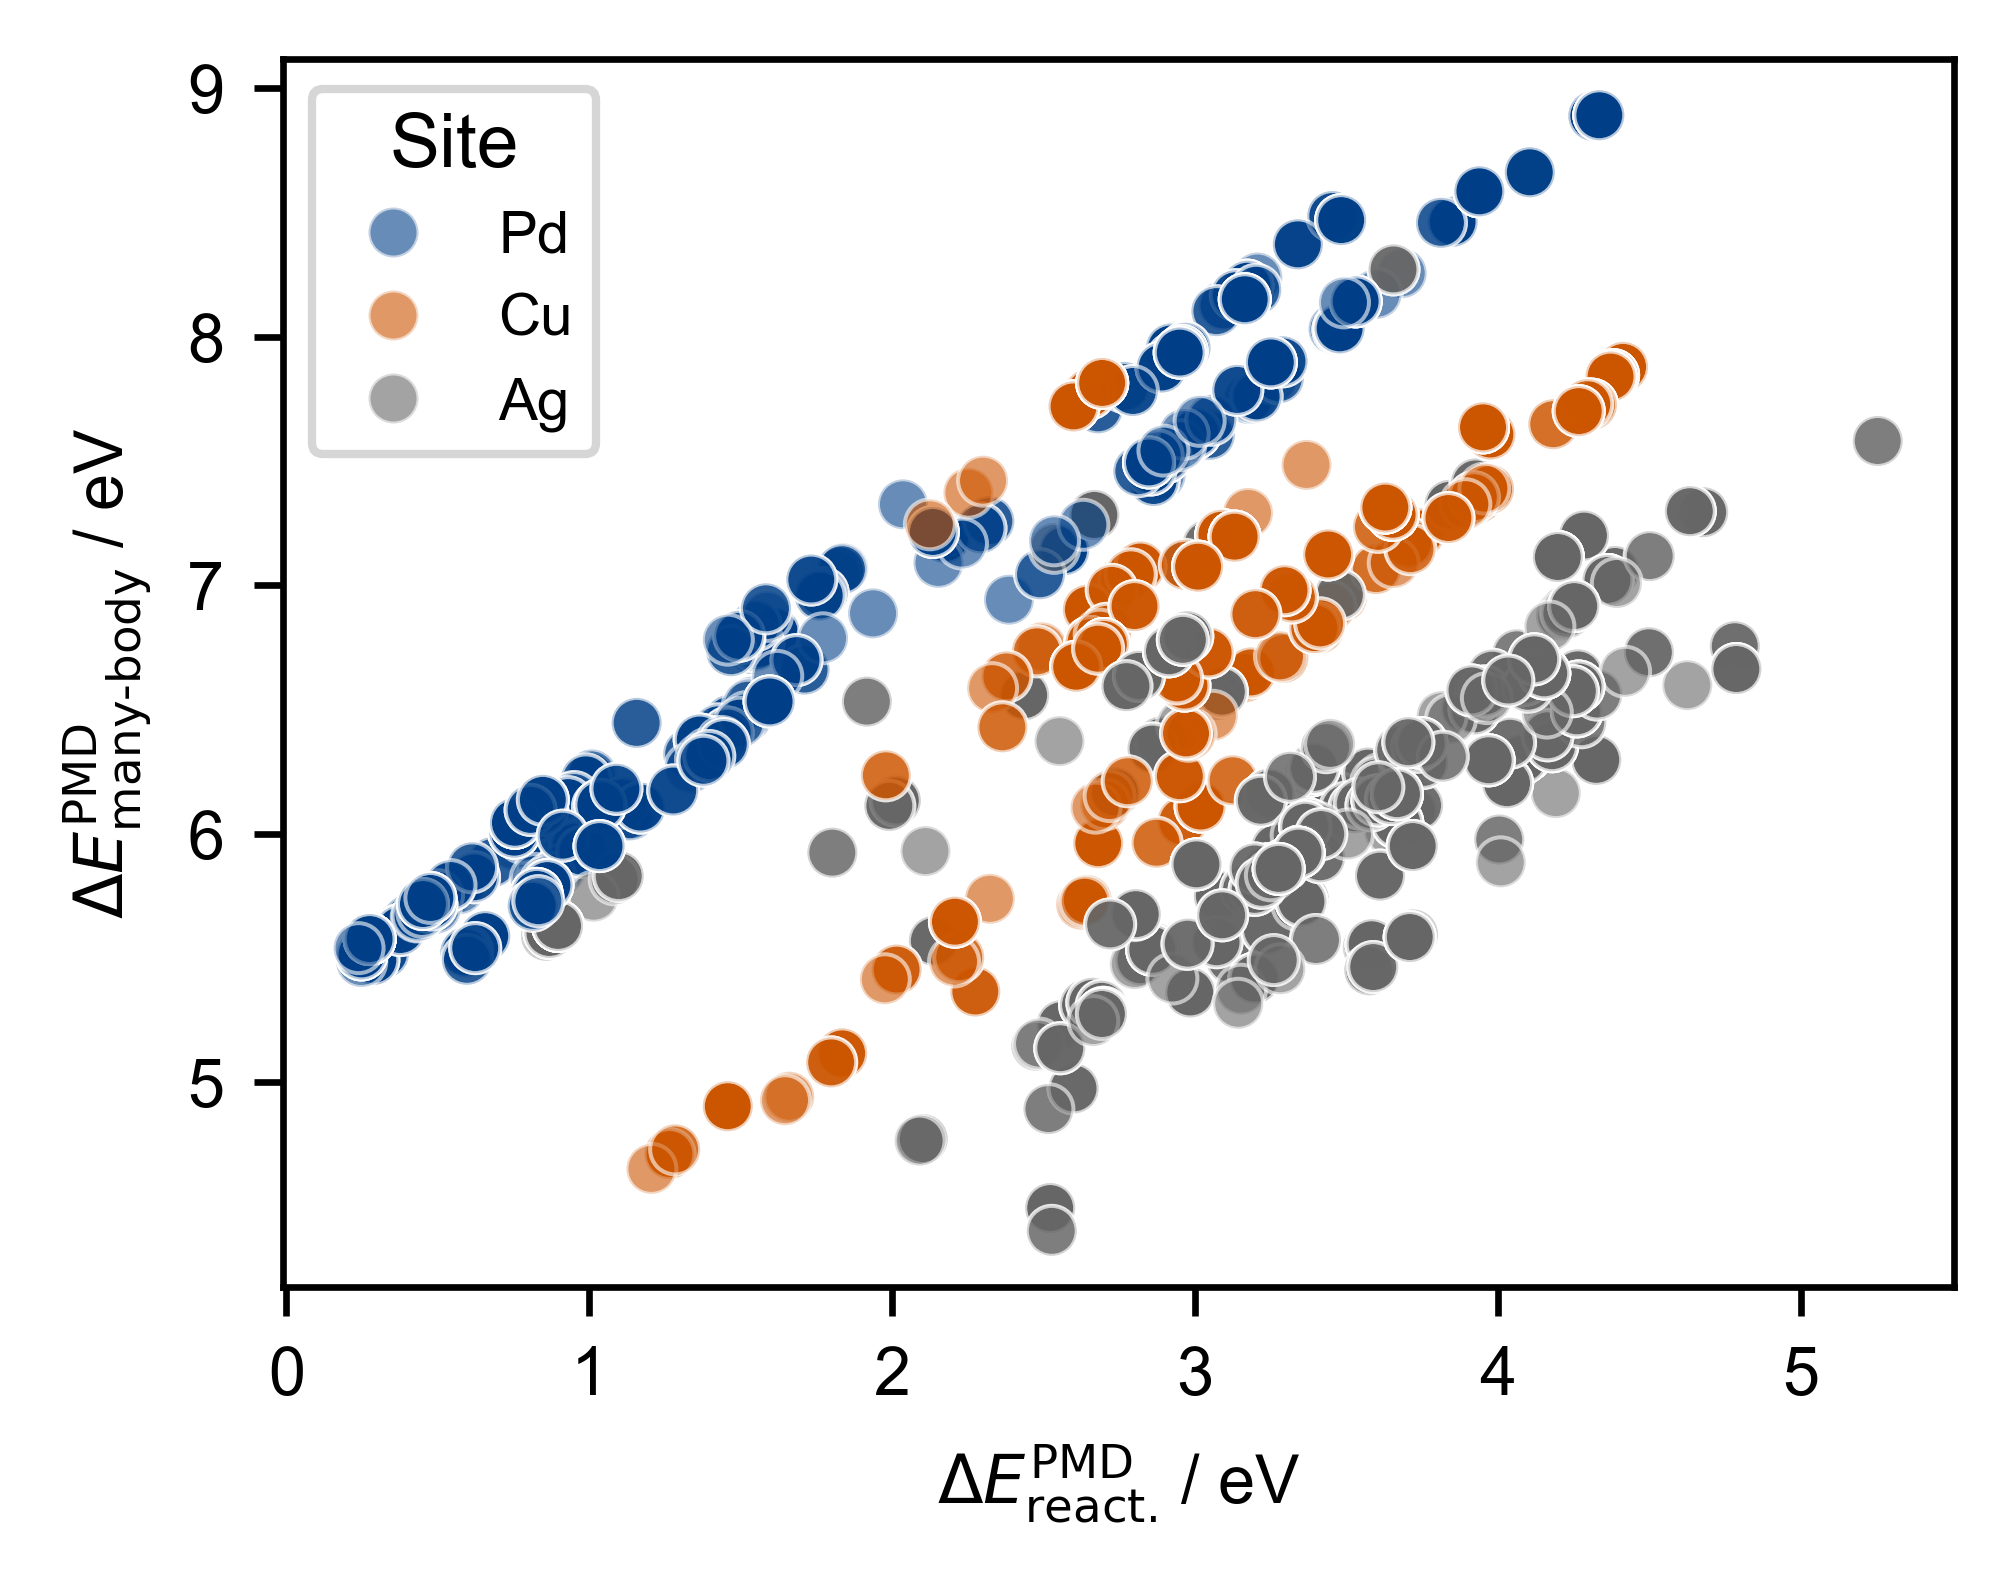

In [40]:
fig, axs = plt.subplots(1,1, figsize = [92/25.6, 68/25.6], dpi=600, sharey=True, sharex=True)

pdf = xdf #[df_reaction_info.first_neighbor == 'Cu']

# sns.scatterplot(data=pdf, x='E_reaction', y='E_barrier', hue='first_neighbor', ax=axs, alpha=0.1, legend=True)

palette = {
    'Cu': '#D55E00',  # warm copper
    'Pd': '#0072B2',  # deep blue
    'Ag': '#999999',  # silver/gray
}

sns.scatterplot(
    data=pdf,
    x='E_reaction',
    y='E_barrier',
    hue='first_neighbor',
    palette=metal_colors,
    # style='first_neighbor',
    # markers=True,
    # hue='site',
    # palette='rainbow',
    ax=axs,
    alpha=0.6,
    legend=True,
    # linewidth=0.1
)

plt.legend(title="Site")
axs.set_xlabel(r'$\Delta E_{\text{react.}}^{\text{PMD}}$ / eV')
axs.set_ylabel(r'$\Delta E_{\text{many-body}}^{\text{PMD}}$ / eV')



Text(0, 0.5, '$\\Delta E_{\\text{many-body}}^{\\text{PMD}}$ / eV')

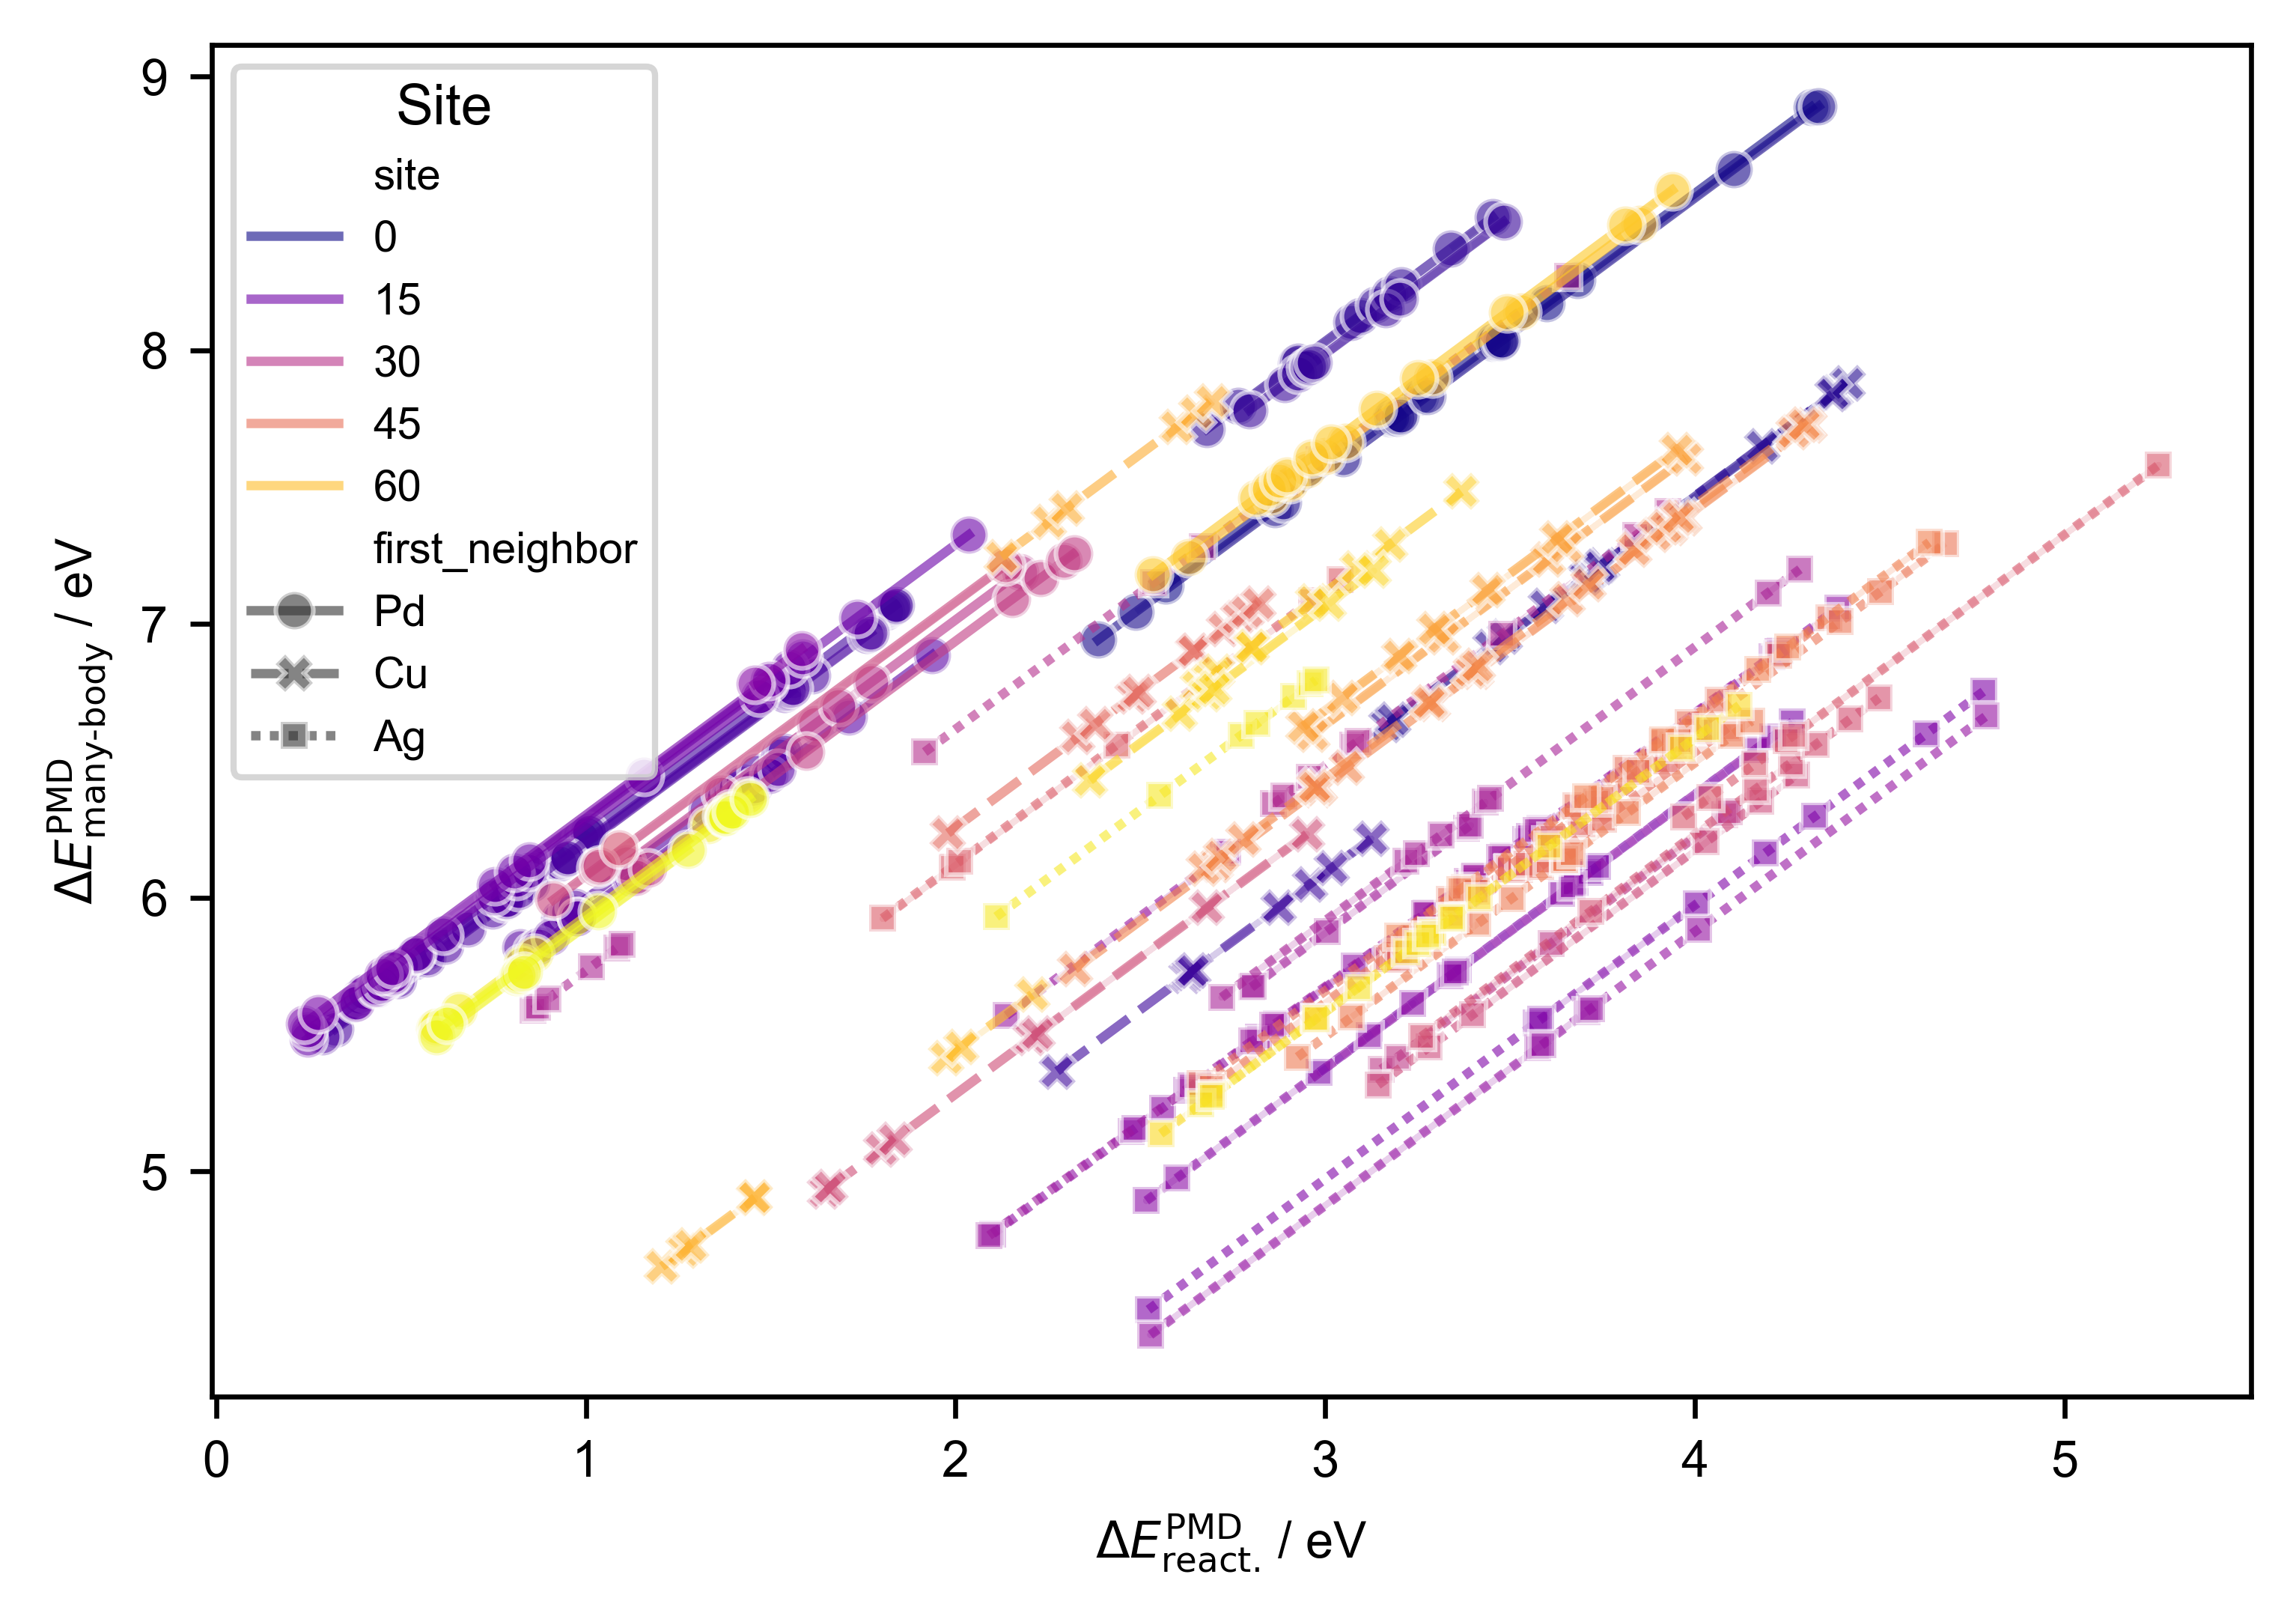

In [41]:
fig, axs = plt.subplots(1,1, figsize = [150/25.6, 100/25.6], dpi=600, sharey=True, sharex=True)

pdf = xdf #[df_reaction_info.first_neighbor == 'Cu']

# sns.scatterplot(data=pdf, x='E_reaction', y='E_barrier', hue='first_neighbor', ax=axs, alpha=0.1, legend=True)

palette = {
    'Cu': '#D55E00',  # warm copper
    'Pd': '#0072B2',  # deep blue
    'Ag': '#999999',  # silver/gray
}

sns.lineplot(
    data=pdf,
    x='E_reaction',
    y='E_barrier',
    # hue='first_neighbor',
    # palette=metal_colors,
    style='first_neighbor',
    markers=True,
    hue='site',
    palette='plasma',
    ax=axs,
    alpha=0.6,
    legend=True,
    # linewidth=0.1
)

plt.legend(title="Site")
axs.set_xlabel(r'$\Delta E_{\text{react.}}^{\text{PMD}}$ / eV')
axs.set_ylabel(r'$\Delta E_{\text{many-body}}^{\text{PMD}}$ / eV')




### prep NEB structures

In [ ]:
# f = Fragment('ClC#[O+]', to_initialize=1).get_conformer(0)

# neb_seed_lst = []
# for i in xdf.index.values:

#     row = xdf.iloc[i].to_dict()
    
#     IS_atoms = particle.copy()
#     i_c = int(row['i_c'])
#     i_o = int(row['i_o'])
#     IS_atoms += Atoms(['C'], [m.grid[i_c]])
#     IS_atoms += Atoms(['O'], [m.grid[i_o]])

#     i_pdm = int(row['i_pmd'])
#     PMD_atoms = particle.copy()
#     _pdm = get_PMD_structure(m.grid[i_pdm], m.normals[i_pdm], row['angle'], fragment=f_PMD_image.get_conformer(0))
#     PMD_atoms += _pdm
    
#     FS_atoms = particle.copy()
#     i_co = int(row['i_pmd'])
#     attach_fragment(
#         FS_atoms,
#         site_dict = {
#                 'coordinates': m.grid[i_co],
#                 'n_vector': m.normals[i_co],
#             },
#         fragment = f,
#         n_rotation = phi,
#         height = 0
#     )

#     neb_seed_lst += [IS_atoms, PMD_atoms, FS_atoms]

# write(f'neb_seed_lst.xyz', neb_seed_lst)

In [26]:
neb_seed_lst = read(f'neb_seed_lst.xyz', index=':')

### analyze neb data

In [27]:
view(neb_seed_lst)

<Popen: returncode: None args: ['/home/ef/venvs/mace_env/bin/python', '-m', ...>

In [ ]:
# from ase.optimize import FIRE, BFGS
# from ase.constraints import FixAtoms
# xx = neb_seed_lst[2].copy()
# mask = [atom.symbol not in ('C', 'O') for atom in xx]
# xx.set_constraint(FixAtoms(mask=mask))
# xx.calc = copy.deepcopy(clean_calc)
# opt = BFGS(xx, trajectory='/mnt/c/Users/ef/Desktop/tmp/relax.traj')
# opt.run(steps=300)

In [ ]:
# view(read('/mnt/c/Users/ef/Desktop/tmp/relax.traj',index=':'))

In [23]:
from ase.mep import NEBTools

_data = DATA_DIR / 'NEBs/OUT_NEB*_final_conv*.traj'
_data = _data.as_posix()
files = glob(_data)

trj = []
chunks = []
for file in files:
    neb_ims = read(file, index=':')
    trj += neb_ims
    chunks.append(neb_ims)

In [21]:
len(chunks) == len(xdf)

True

In [22]:
_df = []
for ims in chunks:
    _df.append(ims[0].info)

_df = pd.DataFrame(_df)

xdf = pd.concat([xdf, _df], axis=1)

In [23]:
d_co = []
bars = []
dEs_neb = []
fs =[]
ets = []
iss = []
fss = []

reference_e = e_particle + isolated_ref['O'] + isolated_ref['C']

for i in range(len(chunks)):
    x = chunks[i][0]
    d = x[[atom.index for atom in x if atom.symbol in ['C','O']]].get_distances(0,1)[0]
    d_co.append(d)
    # ens = [a.get_potential_energy() for a in chunks[i]]
    # bar = np.max(ens) - ens[0]
    
    nebtools = NEBTools(chunks[i])
    bar = nebtools.get_barrier()[0]
    dE_neb = nebtools.get_barrier()[1]
    neb_fmax = nebtools.get_fmax()
    neb_Ets = chunks[i][0].get_potential_energy()+bar - reference_e
    ets.append(neb_Ets)
    iss.append(chunks[i][0].get_potential_energy() - reference_e)
    fss.append(chunks[i][-1].get_potential_energy() - reference_e)
    
    
    dEs_neb.append(dE_neb)
    bars.append(bar)
    fs.append(neb_fmax)

xdf['is_d_co'] = d_co
xdf['neb_barrier'] = bars
xdf['neb_dE'] = dEs_neb
xdf['neb_maxF'] = fs
xdf['neb_Ets'] = ets
xdf['neb_Eis'] = iss
xdf['neb_Efs'] = fss

In [ ]:
import re
import re
import numpy as np
from matplotlib.patches import Wedge

def parse_composition(comp):
    parts = re.findall(r'([A-Z][a-z]?)(\d*)', comp)
    comp_dict = {}
    for element, number in parts:
        comp_dict[element] = int(number) if number else 1
    return comp_dict

import numpy as np
from matplotlib.patches import Wedge

from matplotlib.offsetbox import DrawingArea, AnnotationBbox
from matplotlib.patches import Wedge

def draw_pie(ax, x, y, comp_dict, size=18):
    """
    size is in pixels (constant visual size)
    """
    da = DrawingArea(size, size, 0, 0)
    total = sum(comp_dict.values())
    start = 0

    for element, amount in comp_dict.items():
        fraction = amount / total
        theta1 = start * 360
        theta2 = (start + fraction) * 360

        wedge = Wedge(
            (size/2, size/2),
            size/2,
            theta1,
            theta2,
            facecolor=metal_colors[element],
            edgecolor='black',
            linewidth=0.4
        )
        da.add_artist(wedge)
        start += fraction

    ab = AnnotationBbox(da, (x, y), frameon=False)
    ax.add_artist(ab)



In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

pdf = xdf[
    (xdf.neb_maxF < 0.05) & (xdf.is_d_co > 2.5)
]

xys = {
    0: ['E_reaction', 'E_barrier'],
    1: ['neb_dE', 'neb_barrier'],
}

fig, axs = plt.subplots(1, 2, figsize=[92/25.4, 50/25.4], dpi=600)

# Scatterplots
sns.scatterplot(pdf, y='E_barrier', x='E_reaction',
                hue='first_neighbor', palette=metal_colors, ax=axs[0], legend=False)
sns.scatterplot(pdf, y='neb_barrier', x='neb_dE',
                hue='first_neighbor', palette=metal_colors, ax=axs[1], legend=False)

# Distance threshold in data units
threshold = 0.1  # adjust depending on scale

for i in [0, 1]:
    texts = []
    label_positions = []  # track (x, y, label) of placed texts

    for _, row in pdf.iterrows():
        site = row["site"]
        # Format label
        if isinstance(site, (tuple, list)):
            label = "(" + ", ".join(f"{v:.2f}" for v in site) + ")"
        else:
            label = str(site)

        x = row[xys[i][0]]
        y = row[xys[i][1]]

        # Check proximity: skip if same label is too close to existing one
        skip = False
        for lx, ly, ltext in label_positions:
            if ltext == label and np.hypot(x - lx, y - ly) < threshold:
                skip = True
                break
        if skip:
            continue

        # Place label
        txt = axs[i].text(x, y, label, fontsize=6)
        texts.append(txt)
        label_positions.append((x, y, label))

    # Set aspect
    axs[i].set_aspect('equal', adjustable='box')

    # Adjust text to avoid overlapping other texts
    adjust_text(
        texts,
        ax=axs[i],
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.7, alpha=0.7)
    )
axs[0].set_aspect('equal', adjustable='datalim')
axs[1].set_aspect('equal', adjustable='datalim')


axs[0].set_xlabel(r'$\Delta E_{\text{react.}}^{\text{PMD}}$ / eV')
axs[0].set_ylabel(r'$\Delta E_{\text{many-body}}^{\text{PMD}}$ / eV')

axs[1].set_xlabel(r'$\Delta E_{\text{react.}}^{\text{NEB}}$ / eV')
axs[1].set_ylabel(r'$\Delta E_{\text{barrier}}^{\text{NEB}}$ / eV')


fig.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'adjustText'

In [ ]:
print(axs[1].get_xlim())
print(axs[1].get_ylim())

In [ ]:


pdf = xdf[
    (xdf.neb_maxF < 0.05)
    & (xdf.is_d_co > 2.2)
    # & (xdf.vals_IS < 2.)
    & (xdf.vals_IS < 3.) & (xdf.vals_IS > 2.)
]

fig, axs = plt.subplots(1, 2, figsize=[93/25.4, 50/25.4], dpi=200)

# --- LEFT PLOT ---
axs[0].set_xlim(-6, -1)
axs[0].set_ylim(0,5)


for _, row in pdf.iterrows():
    comp_dict = parse_composition(row.first_neighborhood)
    draw_pie(axs[0], row.neb_dE, row.neb_barrier, comp_dict, 7)

axs[1].set_xlim(0, 5)
axs[1].set_ylim(4,9)
# Pie size scaled to x-range
xrange0 = axs[0].get_xlim()[1] - axs[0].get_xlim()[0]
size0 = 0.03 * xrange0


xrange1 = axs[1].get_xlim()[1] - axs[1].get_xlim()[0]
size1 = 0.03 * xrange1

for _, row in pdf.iterrows():
    comp_dict = parse_composition(row.first_neighborhood)
    draw_pie(axs[1], row.E_reaction, row.E_barrier, comp_dict, 7)

fig.set_layout_engine(layout='tight')


axs[0].set_xlabel("neb_dE")
axs[0].set_ylabel("neb_barrier")

axs[1].set_xlabel("E_reaction")
axs[1].set_ylabel("E_barrier")

# plt.savefig("composition_scatter.pdf")
# plt.close(fig)

In [ ]:
sns.histplot(pdf.vals_IS.values)

In [ ]:
sns.scatterplot(pdf, x='neb_barrier', y='vals_PMD')

In [ ]:
pdf.columns

In [ ]:
mins = xdf.groupby('site')[['neb_barrier', 'E_barrier']].min()
sns.scatterplot(mins, x='neb_barrier', y='E_barrier')

In [ ]:
# minimum neb_barrier per site
neb_min = (
    xdf.groupby('site')['neb_barrier']
    .min()
)

# row index where E_barrier is minimum per site
idx_E = xdf.groupby('site')['E_barrier'].idxmin()

# extract those rows
E_min_rows = xdf.loc[idx_E, ['site', 'E_barrier', 'first_neighborhood']]

# merge together
mins = (
    E_min_rows
    .merge(neb_min, on='site')
)

In [ ]:
len(pdf)

In [ ]:
sns.scatterplot(xdf, x='E_barrier', y='E_reaction', hue='first_neighbor', palette='rainbow')
sns.scatterplot(pdf, y='neb_barrier', x='neb_dE', hue='site', palette='rainbow')

In [ ]:
# mins = xdf.copy()

# mins = mins[mins.neb_barrier<1.5]
# mins = mins[mins.vals_IS<min(mins.vals_IS+1.2)]

# idx = xdf.groupby('site')['E_barrier'].idxmin()
# mins = xdf.loc[idx].copy()


from matplotlib.patches import Wedge
import numpy as np
import re

def draw_pie(ax, x, y, composition, palette, size=0.15):
    # parse composition like Ag2AuCuPd
    parts = re.findall(r'[A-Z][a-z]?\d*', composition)
    
    metals = []
    counts = []
    
    for p in parts:
        metal = re.findall(r'[A-Z][a-z]?', p)[0]
        count = re.findall(r'\d+', p)
        count = int(count[0]) if count else 1
        metals.append(metal)
        counts.append(count)
    
    total = sum(counts)
    angles = np.cumsum([0] + [c/total*360 for c in counts])
    
    for i, metal in enumerate(metals):
        wedge = Wedge((x, y),
                      size,
                      angles[i],
                      angles[i+1],
                      facecolor=palette[metal],
                      edgecolor='black',
                      linewidth=0.3)
        ax.add_patch(wedge)


fig, ax = plt.subplots(figsize=[93/25.4,123/25.4], dpi=600)

ax.set_xlim(mins['neb_barrier'].min() - 0.2,
            mins['neb_barrier'].max() + 0.2)

ax.set_ylim(mins['E_barrier'].min() - 0.2,
            mins['E_barrier'].max() + 0.2)

for _, row in mins.iterrows():
    draw_pie(ax,
             row['neb_barrier'],
             row['E_barrier'],
             row['first_neighborhood'],  # or whatever column holds composition
             metal_colors,
             size=0.05)

ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel("neb_barrier")
ax.set_ylabel("E_barrier")

fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor('none')

plt.savefig("/mnt/c/Users/ef/Desktop/tmp/BARRIER.png", dpi=600, transparent=True, bbox_inches="tight")

In [ ]:
len(pdf.site.unique())

In [ ]:
from ase.utils.forcecurve import fit_images

chunks_dict = {}

for site_i in pdf.site.unique():
    print(f'{site_i = }')
    cdf = pdf[pdf.site==site_i]

    fig, axs = plt.subplots(2,1)

    _chunks = []

    for i in cdf.index.values:

        m = cdf.first_neighbor.loc[i]
        neb_ims = chunks[i]
        nebtools = NEBTools(neb_ims)

        fit = fit_images(neb_ims)

        reference_e = e_particle + isolated_ref['O'] + isolated_ref['C']

        E_abs = [img.get_potential_energy() - reference_e for img in neb_ims]

        axs[1].plot(fit.path, E_abs, 'o', c=metal_colors[m])
        axs[1].plot(fit.fit_path, fit.fit_energies + E_abs[0], c=metal_colors[m])


        axs[0].scatter(['IS' for _ in cdf.vals_IS.values], cdf.vals_IS.values, alpha=0.5, c=metal_colors[m])
        axs[0].scatter(['PMD' for _ in cdf.vals_PMD.values], cdf.vals_PMD.values, alpha=0.5, c=metal_colors[m])
        axs[0].scatter(['FS' for _ in cdf.vals_FS.values], cdf.vals_FS.values, alpha=0.5, c=metal_colors[m])
        
        axs[0].text(2, 9, f'{site_i = }', fontsize=8, color='k', ha='center', va='bottom')
        
        _chunks+=neb_ims

    axs[0].set_ylim(0,11)
    axs[1].set_ylim(-13,-4)


    fig.savefig(f'/mnt/c/Users/ef/Desktop/tmp/tmp_png_neb/{site_i}.png')
    plt.close(fig)
    
    chunks_dict[site_i] = _chunks



# view(chunks[cdf['neb_barrier'].idxmin()])

In [ ]:
view(chunks_dict[70])

In [ ]:
import pandas as pd

def greedy_rank_improvement(df, col1, col2, k):
    df_work = df.copy()
    removed = []

    for _ in range(k):
        base_rho = df_work[col1].corr(df_work[col2], method='spearman')
        best_improve = 0
        best_idx = None

        for idx in df_work.index:
            tmp = df_work.drop(idx)
            rho = tmp[col1].corr(tmp[col2], method='spearman')
            improvement = rho - base_rho

            if improvement > best_improve:
                best_improve = improvement
                best_idx = idx

        if best_idx is None:
            break

        removed.append(best_idx)
        df_work = df_work.drop(best_idx)

    return removed, df_work[col1].corr(df_work[col2], method='spearman')


import pandas as pd

def greedy_stronger_negative(df, col1, col2, k):
    df_work = df.copy()
    removed = []

    for _ in range(k):
        base_rho = df_work[col1].corr(df_work[col2], method='spearman')
        best_improve = 0
        best_idx = None

        for idx in df_work.index:
            tmp = df_work.drop(idx)
            rho = tmp[col1].corr(tmp[col2], method='spearman')
            
            # Improvement = make it more negative
            improvement = base_rho - rho  # bigger positive = stronger negative
            
            if improvement > best_improve:
                best_improve = improvement
                best_idx = idx

        if best_idx is None:
            break

        removed.append(best_idx)
        df_work = df_work.drop(best_idx)

    return removed, df_work[col1].corr(df_work[col2], method='spearman')

In [ ]:
len(pdf)

In [ ]:

sdf = pdf.copy()

grs = []
ks =[1,2,5,10,15,20,25,30, 40, 50]
for k in ks:
    gr = greedy_stronger_negative(sdf, 'neb_barrier', 'E_barrier', k=k)
    grs.append(gr[1])
    

In [ ]:
plt.plot(ks,grs)

In [ ]:
pdf[pdf.index.isin(gr[0])]

In [ ]:
sns.scatterplot(pdf_filtered, x='vals_PMD', y='neb_Ets', hue='site')

In [ ]:
xx = particle.copy()
for i in xdf.index.values[:1]:

    row = xdf.loc[i].to_dict()
    xx+=Atoms(['He'], [m.grid[int(row['i_pmd'])]])
    for _ in range(10):
        xx+=Atoms(['X'], [m.grid[int(row['i_pmd'])] + m.normals[int(row['i_pmd'])]*_*.1 ])

    xx += Atoms(['C'], [m.grid[int(row['i_c'])]])
    xx += Atoms(['O'], [m.grid[int(row['i_o'])]])

    i_co = int(row['i_pmd'])
    co_atoms = Atoms()
    attach_fragment(
        co_atoms,
        site_dict = {
                'coordinates': m.grid[i_co],
                'n_vector': m.normals[i_co],
            },
        fragment = f,
        n_rotation = phi,
        height = 0,
    )
    xx += co_atoms
    

view(xx)

In [ ]:
xdf = xdf.sort_values(by=['vals_PMD'])

In [ ]:
write('/mnt/c/Users/ef/Desktop/tmp/minima_atoms.xyz', get_blenderized(view_trj, hide_spot=np.mean(particle.positions,axis=0)))

In [ ]:
def make_sketch_atoms():
    minima_atoms = Atoms()

    minima_atoms+=Atoms(['He'], [m.grid[i]])
    minima_atoms+=Atoms(['Os'], [o_point])
    minima_atoms+=Atoms(['Cl'], [c_point])

    for i_C_candidate in C_filtered:
    # for i in C_mins:
        minima_atoms+=Atoms(['C'], [m.grid[i_C_candidate]])

    for i_O_candidate in O_filtered:
    # for i in O_mins:
        minima_atoms+=Atoms(['O'], [m.grid[i_O_candidate]])
    
    return minima_atoms# + particle


In [ ]:
angles = [0]
# angles = [phi for phi in range(0,360, 10)]
grid = m.grid

d_min_atom_site = 2.
d_min_co = 0.5
barrier_tol = 1.

reaction_data = {}

for i, angle in enumerate(angles):
    print(f'{angle = }')

    reaction_data[int(angle)] = {}

    aniso_grid_atoms = aniso_trj[i]
    vals_PMD = aniso_grid_atoms.arrays['PMD-CF_aniso']
    vals_CO_PMD = aniso_grid_atoms.arrays['aniso_CO']

    _islands = get_islands_lt_val(
        m,
        vals = vals_PMD,
        lower_than = barrier_tol,
        zero = np.min(vals_PMD)
        )
    
    islands = [isl for isl in _islands if len(isl['original_indices']) > 500] # size of island above threshold

    

    for i_island, island in enumerate(islands):
        
        reaction_data[int(angle)][f'island_{i_island}'] = {}

        islands_inds = island['original_indices']
        vals_PMD_island = vals_PMD[islands_inds]

        PMD_site_i = np.where(vals_PMD == np.min(vals_PMD_island))[0][0]

    #     point = grid[PMD_site_i]
    #     # CO_PMD = pmd_co_vals_dict[angle][PMD_site_i]
    #     CO_PMD = vals_CO_PMD[PMD_site_i]

    #     co_at_site = get_PMD_structure(point, m.normals[PMD_site_i], angle, fragment=f_PMD_image)

    #     o_point = co_at_site[co_at_site.symbols == 'O'].positions[0]
    #     c_point = co_at_site[co_at_site.symbols == 'C'].positions[0]

    #     o_cond = np.where(
    #         ((np.linalg.norm(grid - o_point, axis=1)) > d_min_atom_site) * ((np.linalg.norm(grid - c_point, axis=1)) < d_min_atom_site)
    #     )[0]

    #     c_cond = np.where(
    #         ((np.linalg.norm(grid - c_point, axis=1)) > d_min_atom_site) * ((np.linalg.norm(grid - o_point, axis=1)) < d_min_atom_site)
    #     )[0]

    #     co_cond = np.where(
    #         (np.linalg.norm(grid - point, axis=1)) < d_min_co
    #     )

    #     neighborhood_C_vals = vals_C[c_cond]
    #     neighborhood_O_vals = vals_O[o_cond]
    #     neighborhood_CO_vals = vals_CO[co_cond]

    #     reaction_data[int(angle)][f'island_{i_island}']['CO'] = neighborhood_CO_vals
    #     reaction_data[int(angle)][f'island_{i_island}']['O'] = neighborhood_O_vals
    #     reaction_data[int(angle)][f'island_{i_island}']['C'] = neighborhood_C_vals
    #     reaction_data[int(angle)][f'island_{i_island}']['PMD_coords'] = point
    #     reaction_data[int(angle)][f'island_{i_island}']['PMD-CF'] = np.min(vals_PMD_island)
    #     reaction_data[int(angle)][f'island_{i_island}']['CO_PMD'] = CO_PMD 


In [ ]:
color_dict = {
    'e_particle_C': "#323333",
    'e_particle_O': "#910000",
    'e_C-O': "#fdfdfd",
    'sum_two_body': "#2d703b",
    'd_body': "#b1008a",
}

In [ ]:
# import itertools

# def _plot(data, ax):
#     ini_vals = [np.sum(p) for p in itertools.product(data['C'], data['O'])]
#     sns.violinplot(x=["*C" for _ in data['C']], y = data['C'], ax=ax, color = color_dict['e_particle_C'], linewidth=0.5)
#     sns.violinplot(x=["*O" for _ in data['O']], y = data['O'], ax=ax, color = color_dict['e_particle_O'], linewidth=0.5)
#     sns.violinplot(x=["IS"], y = [min(ini_vals)], ax=ax, color = color_dict['sum_two_body'], linewidth=0.5)
#     sns.violinplot(x=['PMD' for _ in [data['PMD-CF']]], y = data['PMD-CF'], ax=ax, color = color_dict['e_C-O'], linewidth=0.5)
#     sns.violinplot(x=["FS"], y = [min(data['CO'])], ax=ax, color = color_dict['sum_two_body'], linewidth=0.5)
#     sns.violinplot(x=['*CO' for _ in data['CO']], y = data['CO'], ax=ax, linewidth=0.5)

# for key in reaction_data[0].keys():

#     fig, axs = plt.subplots(6,6, figsize = [180/25.6, 170/25.6], dpi=300, sharey=True, sharex=True)
    
#     for ax in axs[:,0]:
#         ax.set_ylabel('ΔE / eV')
#     for ax in axs[-1,:]:
#         ax.tick_params(axis='x', rotation=45)

#     axs = axs.flatten()

#     for i, angle in enumerate(angles):

    
#         plot_dict = reaction_data[angle]
#         if key in plot_dict.keys():
#             data = plot_dict[key]
#         ax = axs[i]
#         _plot(data, ax)
#         ax.text(0.05, 0.95, f'α={angle}°', 
#             transform=ax.transAxes,
#             verticalalignment='top',
#             horizontalalignment='left',
#             fontsize=7)


#     for ax in axs:
#         if not ax.has_data():
#             fig.delaxes(ax)
    

#     fig.set_layout_engine(layout='tight')
#     fig.savefig(f'/mnt/c/Users/ef/Desktop/tmp/cft_{key}.png')


In [ ]:
island_overview = []

for i_island, k in enumerate(reaction_data[0].keys()):
    print(k)    
    for angle in angles:
        
        if k not in reaction_data[angle].keys():
            continue

        info = {
            'CO_PMD': reaction_data[angle][k]['CO_PMD'],
            'angle': angle,
            'island': i_island
        }
        
        island_overview.append(info)

island_overview = pd.DataFrame(island_overview)

In [ ]:
pdf = island_overview.copy()
# pdf.sort_values(by=['CO_PMD']) #[island_overview.island == 0]
sns.violinplot(data=pdf, x = 'island', y='CO_PMD', hue='island', palette='plasma')

In [ ]:
angles = [120]
# trj = [Atoms() for _ in angles]
xx = Atoms()

for i in [i_site]:
    for i_phi, phi in enumerate(angles):
    # for i_phi, f in enumerate(fs):

        x = particle.copy() #Atoms()

        attach_fragment(
            x,
            site_dict = {
                    'coordinates': m.grid[i],
                    'n_vector': m.normals[i],
                },
            fragment = get_neb_probe(PMD_image, keep=['C','O']).get_conformer(0),
            n_rotation = phi,
            height = 0,
        )
        xx = xx[[]]
        xx += Atoms(['He'],[m.grid[i]])
        # trj[i_phi]+=Atoms(['He' for _ in range(100)], [point+_d/40*m.normals[i] for _d in range(100)])
        # trj[i_phi]+=x
        # trj.append(x)
# trj += particle.copy()

In [ ]:
write(DATA_DIR / 'PMD_site_marker.xyz', xx)

## plot spectral

In [ ]:
relaxed_trj = read('/home/ef/liac22_home/git/CFT/examples/HEA_toy/gly_spectral/out_traj.xyz', index=':')

data = pd.DataFrame([a.info for a in relaxed_trj])
e_ref = data[data.d > (data.d.max() - 0.01)].en.max()
data['en_rel'] = data['en'] - e_ref


In [ ]:

# --- Adjustable Parameters ---
figsize = (71/25.4, 87.629/25.4)  # width, height in inches
fontsize = 7       # font size for labels and ticks
rows_per_bar = 10    # height of each KDE stripe
gap = 5              # vertical space between stripes
E_bins = 700         # Number of points in the energy grid

# --- Explicitly Set Constant Kernel Standard Deviation (Sigma) ---
constant_kernel_sigma = 0.02 # This is the "sigma" you want for each kernel

# --- Data Preparation ---
d_unique = np.sort(data['d'].unique())

# --- Energy range ---
E_min = -1.2
E_max = 0.2
E_grid = np.linspace(E_min, E_max, E_bins)

# --- Manual Gaussian KDE Function ---
def manual_gaussian_kde(data_points, evaluation_grid, kernel_sigma):
    """
    Performs a 1D Gaussian Kernel Density Estimation manually.
    """
    if len(data_points) == 0:
        return np.zeros_like(evaluation_grid)

    density = np.zeros_like(evaluation_grid, dtype=float)
    
    # Calculate pre-factors for the Gaussian function
    # Gaussian PDF: (1 / (sigma * sqrt(2 * pi))) * exp(-0.5 * ((x - mu) / sigma)^2)
    # We sum densities, so the (1/N) normalization usually applied after summation.
    # We normalize each row to max 1 later, so the constant pre-factor (1 / (sigma * sqrt(2 * pi)))
    # can be applied once after summation or effectively skipped if we normalize to max 1 anyway.
    # For now, let's keep it simple and sum un-normalized Gaussians, then normalize the total.

    for x_i in data_points:
        # Add a Gaussian centered at x_i to the density
        # The (x - mu)^2 part
        exponent = -0.5 * ((evaluation_grid - x_i) / kernel_sigma)**2
        # np.exp(exponent) is the un-normalized Gaussian shape
        density += np.exp(exponent)
    
    # Optional: Initial normalization by number of points to get actual density values
    # if len(data_points) > 0:
    #    density /= len(data_points)
    # The (1 / (sigma * sqrt(2 * pi))) factor could also be applied here
    # density /= (kernel_sigma * np.sqrt(2 * np.pi)) * len(data_points)

    return density

# --- Heatmap initialization ---
heatmap_height = len(d_unique) * (rows_per_bar + gap) - gap
heatmap = np.ones((heatmap_height, E_bins)) * np.nan

# --- Build KDE for each distance and populate heatmap ---
for i, di in enumerate(d_unique):
    Ei_values = data.loc[data['d'] == di, 'en_rel'].to_numpy()

    # Perform manual KDE
    density = manual_gaussian_kde(Ei_values, E_grid, constant_kernel_sigma)
    
    # Handle cases where density might be all zeros (e.g., no data points, or points outside grid)
    if np.max(density) > 0:
        density /= np.max(density)  # Normalize density to [0, 1] per row
    else:
        # If max density is 0, it means no meaningful KDE, so set to zeros
        density = np.zeros_like(E_grid)

    row_start = i * (rows_per_bar + gap)
    row_end = row_start + rows_per_bar
    if row_end > heatmap_height:
        row_end = heatmap_height
    heatmap[row_start:row_end, :] = np.tile(density, (row_end - row_start, 1))

# --- Plotting ---
fig, ax = plt.subplots(figsize=figsize, dpi=600)

sns.heatmap(
    heatmap,
    ax=ax,
    cmap='plasma',
    cbar=True,
    linewidths=0,
    linecolor='none',
    mask=np.isnan(heatmap)
)

# --- Add Black Box Outlines ---
for i in range(len(d_unique)):
    y0 = i * (rows_per_bar + gap)
    rect = Rectangle(
        (0, y0),
        E_bins,
        rows_per_bar,
        linewidth=0.8,
        edgecolor='black',
        facecolor='none'
    )
    ax.add_patch(rect)

# --- Flip Y axis (lowest d at bottom) ---
ax.invert_yaxis()

# --- Set Energy (X) Ticks ---
tick_step_x = 0.5
E_ticks = np.arange(E_min, E_max + tick_step_x/2, tick_step_x)
x_tick_idx = [np.argmin(np.abs(E_grid - t)) for t in E_ticks]
ax.set_xticks(x_tick_idx)
ax.set_xticklabels([f"{x:.1f}" for x in E_ticks], fontsize=fontsize)
ax.set_xlabel("Energy (en_rel)", fontsize=fontsize)

# --- Set Distance (Y) Ticks ---
y_tick_idx = [i * (rows_per_bar + gap) + rows_per_bar / 2 for i in range(len(d_unique))]
ax.set_yticks(y_tick_idx)
ax.set_yticklabels([f"{val:.2f}" for val in d_unique], fontsize=fontsize)
ax.set_ylabel("Distance (d)", fontsize=fontsize)

# --- Title ---
ax.set_title(f"KDE Heatmap of Energy per Distance (Manual Kernel Sigma: {constant_kernel_sigma})", fontsize=fontsize, pad=10)

# --- Adjust Colorbar ---
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label('Normalized Density', fontsize=fontsize)

plt.tight_layout()
plt.show()

In [ ]:
data1 = pd.read_csv('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/data_4147.csv')
data2 = pd.read_csv('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/data_3469.csv')

for data in [data1,data2]:
    data['en_rel'] = data['en']-data.en.values[-1]

In [ ]:
atoms1 = read('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/out_traj_4147.xyz', index=1500)
atoms2 = read('/home/ef/liac22_home/git/CFT/examples/HEA_toy/N2H_anisotropic/out_traj_3469.xyz', index=1500)

In [ ]:
write('/mnt/c/Users/ef/Desktop/tmp/top_1500.xyz', atoms2)
write('/mnt/c/Users/ef/Desktop/tmp/bridge_1500.xyz', atoms1)

In [ ]:
sns.histplot(data1.en_rel.values)

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Data ---
# # data = data[data.d > -.1]
# r_vals = data["r"].to_numpy()
# d_vals = data["d"].to_numpy()
# en_vals = data["en_rel"].to_numpy()

# # --- Plot setup ---
# fig, ax = plt.subplots(figsize=(8, 5))
# angle_in_degrees = True  # Change to False if already radians

# if angle_in_degrees:
#     r_vals = np.deg2rad(r_vals)  # optional, keep consistent if polar coordinates used

# # --- Plot one line per distance ---
# for di in np.sort(data["d"].unique()):
#     mask = data["d"] == di
#     r_i = r_vals[mask]
#     en_i = en_vals[mask]

#     # Sort by r for smooth line
#     idx = np.argsort(r_i)
#     r_i = r_i[idx]
#     en_i = en_i[idx]

#     ax.plot(
#         r_i,
#         en_i,
#         label=f"d = {di:.2f}",
#         linewidth=1.2,
#         alpha=0.9
#     )

# # --- Labels & formatting ---
# ax.set_xlabel("Angle (radians)" if not angle_in_degrees else "Angle (r, degrees)", fontsize=10)
# ax.set_ylabel("Energy (en_rel)", fontsize=10)
# ax.set_title("Energy vs Angle for Each Distance (d)", fontsize=11)
# ax.legend(title="Distance (d)", fontsize=8)
# ax.grid(True, linestyle="--", alpha=0.4)

# plt.tight_layout()
# plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import griddata

# # --- Parameters ---
# figsize_mm = (36, 16)  # width, height in millimeters
# figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
# vmin, vmax = -1, 0
# cmap = "plasma"
# angle_in_degrees = True  # False if already radians
# highlight_index = 1500   # index of data point to mark

# def make_polar(ax, df):
#     r_vals = df["r"].to_numpy()
#     d_vals = df["d"].to_numpy()
#     en_vals = df["en_rel"].to_numpy()

#     if angle_in_degrees:
#         r_vals = np.deg2rad(r_vals)

#     # --- Grid ---
#     r_bins, d_bins = 300, 300
#     r_grid = np.linspace(r_vals.min(), r_vals.max(), r_bins)
#     d_grid = np.linspace(d_vals.min(), d_vals.max(), d_bins)
#     R, D = np.meshgrid(r_grid, d_grid)

#     # --- Interpolate energy onto grid ---
#     Z = griddata((r_vals, d_vals), en_vals, (R, D), method="linear", fill_value=np.nan)

#     # --- Plot heatmap ---
#     ax.pcolormesh(R, D, Z, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)

#     # --- Mark specific data point ---
#     if highlight_index < len(df):
#         r_pt = r_vals[highlight_index]
#         d_pt = d_vals[highlight_index]
#         ax.plot(r_pt, d_pt, "x", color="white", markersize=2, mew=0.8)

#     # --- Minimal style ---
#     ax.set_theta_zero_location("N")
#     ax.set_theta_direction(-1)
#     ax.set_rlabel_position(90)
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])
#     ax.grid(False)
#     ax.set_frame_on(False)


# # --- Subplots ---
# fig, axes = plt.subplots(1, 2, figsize=figsize_inch, subplot_kw=dict(projection="polar"), dpi=600)

# make_polar(axes[0], data1)
# make_polar(axes[1], data2)

# plt.subplots_adjust(wspace=0.02, hspace=0)
# plt.show()
